In [1]:
import numpy as np 
import pandas as pd 
from glob import glob
from tqdm import tqdm
from pybedtools import BedTool
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.gridspec as gridspec
from datasketch import MinHash
import edlib
from scipy.stats import ttest_ind
from scipy.stats import mannwhitneyu
import gzip 
import re
import warnings
warnings.filterwarnings("ignore")
from matplotlib.patches import Rectangle
import edlib
from matplotlib.collections import BrokenBarHCollection
import os 
from collections import Counter
import zlib
from matplotlib import cm, colors
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform

In [2]:


tar1_df = pd.read_csv("data_for_submission/all_tar1.clean.bed", 
                      sep="\t", 
                      header=None, 
                      usecols=[0,1,2,3],
                      names=['contig','start','stop','sat_name'])

telo_df = pd.read_csv("data_for_submission/all_telos.bed.gz", 
                      sep="\t", 
                      header=None, 
                      usecols=[0,1,2,3],
                      names=['contig','start','stop','direction'])

# compute telomere end coordinate
telo_df["tel_end"] = telo_df.apply(
    lambda r: r.stop if r.direction == "-" else r.start,
    axis=1
)

# merge telomere info into satellite intervals
m = tar1_df.merge(telo_df[["contig", "tel_end"]], on="contig")

# keep only intervals that fall within 10kb of tel_end
res = m[
    (m["start"] <= m["tel_end"] + 10_000) &
    (m["stop"]  >= m["tel_end"] - 10_000)
]

In [10]:
# functions for coloring tvrs

DNA_COMP = str.maketrans("ACGTacgtnN", "TGCAtgcaNn")
def rc(s): 
    return s.translate(DNA_COMP)[::-1]

def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=256):
    base = cm.get_cmap(cmap) if isinstance(cmap, str) else cmap
    return colors.ListedColormap(base(np.linspace(minval, maxval, n)))

class HashKmerColorManager:
    def __init__(self, k=6, canonical="CCCTAA",
                 cmap="cubehelix_r", cmap_min=0.15, cmap_max=0.95,
                 tie_rc=False, pin_canonical=True):
        self.k = k
        self.canonical = canonical.upper()
        self.cmap = truncate_colormap(cmap, cmap_min, cmap_max)
        self.tie_rc = tie_rc
        self.pin_canonical = pin_canonical
        self.cache_hex = {}
        self.cache_rgba = {}
        self.gray_hex = "#bfbfbf"
        self.gray_rgba = (0.75, 0.75, 0.75, 1.0)

    def _key(self, kmer: str) -> str:
        kmer = kmer.upper()
        if self.tie_rc:
            rcmer = rc(kmer)
            return kmer if kmer <= rcmer else rcmer
        return kmer

    def _scalar(self, key: str) -> float:
        """CRC32 hash -> [0,1) scalar."""
        h = zlib.crc32(key.encode("utf-8")) & 0xffffffff
        return (h / 0xffffffff)  # normalized float 0–1

    def _is_canonical_fragment(self, kmer: str) -> bool:
        return len(kmer) > 0 and kmer.upper() == self.canonical[:len(kmer)]

    def color_hex(self, kmer: str) -> str:
        key = self._key(kmer)
        if key in self.cache_hex:
            return self.cache_hex[key]

        if self.pin_canonical and self._is_canonical_fragment(key):
            self.cache_hex[key] = self.gray_hex
            return self.gray_hex

        s = self._scalar(key)
        rgba = self.cmap(s)
        rgb = tuple(int(255 * c) for c in rgba[:3])
        hexcol = f"#{rgb[0]:02x}{rgb[1]:02x}{rgb[2]:02x}"
        self.cache_hex[key] = hexcol
        return hexcol

    def color_rgba(self, kmer: str):
        key = self._key(kmer)
        if key in self.cache_rgba:
            return self.cache_rgba[key]

        if self.pin_canonical and self._is_canonical_fragment(key):
            self.cache_rgba[key] = self.gray_rgba
            return self.gray_rgba

        s = self._scalar(key)
        rgba = self.cmap(s)
        self.cache_rgba[key] = rgba
        return rgba

k=6
cmgr = HashKmerColorManager(
    k=k,
    canonical="TTAGGG",
    cmap="turbo",   
    cmap_min=0.05,     # skip pale start
    cmap_max=0.95,    # skip darkest end
    tie_rc=True,
    pin_canonical=False
)



def get_label_from_series(series: pd.Series) -> str:
    """
    split first non-null value in series by '#' and combine
    first two parts with '_', going from  'HG01346#2#JBHDSS383291.1' → 'HG01346_2'.
    """
    if series.empty or series.isna().all():
        return "unknown"
    first_val = series.dropna().iloc[0]
    parts = str(first_val).split("#")
    if len(parts) >= 2:
        return f"{parts[0]}_{parts[1]}"
    return parts[0]
        
    
    
chrom_alias = pd.read_csv('data_for_submission/all_diploid_alias.txt',
                          sep="\t",
                          header=None,
                          names=['id','chrom','contig']
                         )

# build id -> chrom mapping from chrom_alias
id_to_chr = dict(zip(chrom_alias['id'], chrom_alias['chrom']))

def read_in_tsv(file,id_to_chr):
    
    col_names = ['chrom',
         'centering_position',
         'strand',
         'subset_sequence',
         'reference_start',
         'reference_end',
         'query_name',
         'RG',
         'HP',
         'centered_query_start',
         'centered_query_end',
         'query_length',
         '5mC_pos',
         '5mC_score',
         'query_sequence']
    
    
    
    sample_id = file.split('.')[0].split('/')[-1]
    sample_tsv = pd.read_csv(file,sep="\t",index_col=False,header=None,
                        usecols = [0,1,2,3,4,5,6,7,8,9,10,11,14,15,21],names=col_names,skiprows=1)
    
    sample_id = file.split('.')[0]

       # map sample contig ids to base chromosome names (e.g., "chr1")
    sample_tsv['chr_base'] = sample_tsv['chrom'].map(id_to_chr)

    # if centering_position > 100kb → 'q', else 'p'
    threshold = 100_000
    sample_tsv['chrom_assignment'] = (
        sample_tsv['chr_base'] + np.where(sample_tsv['centering_position'].astype(int) > threshold, 'q', 'p')
    )

    sample_tsv.drop(columns=['chr_base'], inplace=True)

    return sample_tsv

def rotations(s: str):
    return [s[i:] + s[:i] for i in range(len(s))]

def ID_TVR_PHASE_DISRUPTION_SIMPLIFIED(s):
    # determine strand via cyclic 6-mer matches (Kept for robust strand detection)
    plus6  = rotations("CCCTAA")   # cyclic perms (plus)
    minus6 = rotations("TTAGGG")   # cyclic perms (minus)

    pat_plus6  = re.compile(r"(?=(?:%s))" % "|".join(plus6),  re.I)
    pat_minus6 = re.compile(r"(?=(?:%s))" % "|".join(minus6), re.I)

    plus_idx  = np.fromiter((m.start() for m in pat_plus6.finditer(s)),  dtype=int)
    minus_idx = np.fromiter((m.start() for m in pat_minus6.finditer(s)), dtype=int)

    is_plus  = (plus_idx.size >= minus_idx.size)
    true_idx = plus_idx if is_plus else minus_idx
    
    # If there are no telomeric patterns at all, there are no phase disruptions to map
    if true_idx.size == 0:
        return np.empty((0, 2), dtype=int)

    L = len(s)

    # 2) Find canonical 6-mer on chosen strand and build a boolean mask
    canon = "CCCTAA" if is_plus else "TTAGGG"
    pat_canon = re.compile(rf"(?={canon})", re.I)
    canon_idx = np.fromiter((m.start() for m in pat_canon.finditer(s)), dtype=int)

    # Use the fast difference array to mark all bases covered by the canonical motif
    diff = np.zeros(L + 1, dtype=np.int16)
    if canon_idx.size > 0:
        np.add.at(diff, canon_idx, 1)
        np.add.at(diff, canon_idx + 6, -1)
        
    canon_mask = np.cumsum(diff)[:L] > 0

    # 3) Return all continuous spans where the sequence is NOT canonical
    low = ~canon_mask  # Invert the mask: True where it is a variant/disruption
    d = np.diff(np.pad(low.astype(np.int8), (1, 1)))
    starts = np.where(d == 1)[0]
    ends   = np.where(d == -1)[0]
    
    # Return as [start, length] pairs
    spans  = np.column_stack([starts, ends - starts]).astype(int)
    
    return spans
    


def assignTVRAndAddTelomereSequenceColumn(tsv, 
              minimum_cutoff_for_read_length = 100, 
              maximum_cutoff_for_tvr_length = 300):
    
    teloseqs, tvrs = [], []
    
    for qn, grp in tsv.groupby("query_name", sort=False):
        seq = grp["query_sequence"].iloc[0]
        qe  = int(grp["centered_query_end"].iloc[0])

        if not isinstance(seq, str) or qe < minimum_cutoff_for_read_length:
            teloseq = ""
            tvr = np.empty((0,2), int)
        else:
            qe = min(qe, len(seq))
            teloseq = seq[-qe:]
            tvr = ID_TVR_PHASE_DISRUPTION_SIMPLIFIED(teloseq)
            # optionally filter overly long ones
            tvr = tvr[tvr[:,1] <= maximum_cutoff_for_tvr_length] if tvr.size else tvr

        # assign the same teloseq/tvr to all rows in this group
        teloseqs.extend([teloseq] * len(grp))
        tvrs.extend([tvr] * len(grp))

    # assign new columns back to tsv
    tsv = tsv.assign(teloseq=teloseqs, tvr=tvrs)
    
    return tsv

def sort_by_max_TVR_start(all_tsvs, chrom, dist_bp=300):
    
    ## need to max mean TVR start less than
    
    all_max_tvr_starts = []
    
    for tsv in all_tsvs:
        # 1. Restrict to the desired chromosome
        tmp = tsv[tsv.chrom_assignment == chrom]

        # 2. Extract valid TVRs (stored as arrays in the 'tvr' column)
        tvr_starts = []
        for arr in tmp.get("tvr", []):
            if isinstance(arr, np.ndarray) and arr.size:
                # filter by: start > 6 and size < dist_bp
                valid = arr[(arr[:, 0] < dist_bp) & (arr[:, 1] >= 30)]
                if valid.size:
                    tvr_starts.append(valid[:, 0].max())

        # 3. Take maximum valid TVR start or NaN if none
        max_start = np.nanmedian(tvr_starts) if tvr_starts else np.nan
        all_max_tvr_starts.append(max_start)

    # 4. Sort by that metric
    sort_order = np.argsort(np.nan_to_num(all_max_tvr_starts, nan=np.inf))
    return sort_order

def _cluster_contigs_for_end(similarity_df, chrom_end, contigs_present, sim_col="sim_t200"):
    """
    Subsample similarity_df to contigs_present at chrom_end,
    build similarity matrix, do hierarchical clustering, and return ordered contigs.
    """
    # Keep only rows for this arm/end and where both contigs are present in the data we’ll plot
    sim_sub = similarity_df[
        (similarity_df["assignment"] == chrom_end) &
        (similarity_df["contig_i"].isin(contigs_present)) &
        (similarity_df["contig_j"].isin(contigs_present))
    ].copy()

    # If we don’t have enough pairs to cluster, fall back to a simple, stable order
    uniq_in_sim = pd.unique(
        pd.concat([sim_sub["contig_i"], sim_sub["contig_j"]], ignore_index=True)
    )
    uniq_in_sim = [c for c in contigs_present if c in set(uniq_in_sim)]
    leftovers   = [c for c in contigs_present if c not in set(uniq_in_sim)]

    if len(uniq_in_sim) < 2:
        # Nothing to cluster; just return present contigs (keep everything, ordered)
        return uniq_in_sim + leftovers

    # Build symmetric similarity matrix on uniq_in_sim
    S = pd.DataFrame(index=uniq_in_sim, columns=uniq_in_sim, dtype=float)
    S.iloc[:] = np.nan

    # Fill from pairs
    for _, r in sim_sub.iterrows():
        ci, cj, s = r["contig_i"], r["contig_j"], r[sim_col]
        if ci in S.index and cj in S.columns:
            S.loc[ci, cj] = s
            S.loc[cj, ci] = s

    # symmetrize and fill missing:
    #   - take max to be safe against tiny asymmetries
    #   - fill nans with 0.0 similarity
    S = np.maximum(S.values, S.values.T)
    S = pd.DataFrame(S, index=uniq_in_sim, columns=uniq_in_sim)
    np.fill_diagonal(S.values, 1.0)
    S = S.fillna(0.0)

    # convert similarity to distance and cluster
    D = 1.0 - S
    np.fill_diagonal(D.values, 0.0)
    Z = linkage(squareform(D.values, checks=False), method="average")
    order_idx = leaves_list(Z)

    # ordered contigs we could cluster + any leftovers that had no edges
    ordered = list(S.index[order_idx]) + leftovers
    return ordered

def plotTVRs(
    all_tsvs, chrom_end,
    similarity_df,
    sim_col="sim_t200",              
    dist_bp=5_000,
    figsize=(5,9),
    only_labels=None,
    spacing_between_mols=2,
    spacing_between_individuals=5,
    cmgr=cmgr,                       
    min_reads_per_group=5,
    min_tvr_size=1,
    max_tvr_size=1_000,
    population_df=None,           
    out_name=None,flip=False
):
   # super-pop colors
    _POP_COLORS = {"AFR":"red", "EUR":"blue", "AMR":"gold", "EAS":"purple", "SAS":"green"}
    pop_lookup = {}
    if population_df is not None and not population_df.empty:
        pop_lookup = population_df.set_index("Sample")["Superpopulation"].to_dict()

    fig, ax = plt.subplots(figsize=figsize)
    canonical_gray = "whitesmoke"
    y_offset = 0
    y_labels, y_positions = [], []
    side_spans = []  # (y0, y1, label) for right-side bars

    # 1) contigs present
    contigs_present = []
    for tsv in all_tsvs.values():
        tmp = tsv[tsv.chrom_assignment == chrom_end]
        if "chrom" in tmp.columns and len(tmp):
            contigs_present.extend(tmp["chrom"].astype(str).unique().tolist())
    contigs_present = list(dict.fromkeys(contigs_present))

    # 2) cluster those contigs
    contig_order = _cluster_contigs_for_end(
        similarity_df=similarity_df,
        chrom_end=chrom_end,
        contigs_present=contigs_present,
        sim_col=sim_col
    )
    if flip:
        contig_order = contig_order[::-1]
    # 3) plot in clustered order
    for contig in contig_order:
        row_start = y_offset
        any_plotted = False
        first_label_for_contig = None

        
        min_y_for_bars = None
        max_y_for_bars = None

        for tsv in all_tsvs.values():
            tmp = tsv[(tsv.chrom_assignment == chrom_end) & (tsv.chrom == contig)]
            if tmp.empty:
                continue

            grouped = (
                tmp.assign(span=tmp["centered_query_end"].astype(int))
                   .sort_values("span", ascending=True)
                   .groupby(["chrom", "centering_position"])
            )

            for (chrom_, center_pos), group in grouped:
                if len(group) < min_reads_per_group:
                    continue

                label = get_label_from_series(group["chrom"])
                if (only_labels is not None) and (label not in only_labels):
                    continue

                for row in group.itertuples():
                    seq = getattr(row, "query_sequence")
                    qe  = int(getattr(row, "centered_query_end"))
                    if not isinstance(seq, str) or qe < 1_000:
                        continue

                    teloseq = getattr(row, "teloseq")
                    L = min(qe, dist_bp)
                    tvr = getattr(row, "tvr")

                    segments_by_color = {}
                    for start, length in zip(list(tvr[:, 0]), (tvr[:, 1])):
                        if length < min_tvr_size or length > max_tvr_size:
                            continue
                        if start >= dist_bp:
                            break

                        pos = int(start)
                        end = start + length
                        while pos < end:
                            frag_len = min(k, end - pos)   
                            frag_end = pos + frag_len
                            frag = teloseq[pos:frag_end]
                            if not frag:
                                break
                            color = cmgr.color_rgba(frag)
                            run_end = frag_end
                            stride = frag_len
                            while run_end + stride <= end and teloseq[run_end:run_end + stride] == frag:
                                run_end += stride
                            segments_by_color.setdefault(color, []).append((pos, run_end - pos))
                            pos = run_end

                    if len(segments_by_color) < 1:
                        continue

                    
                    ax.add_patch(Rectangle(
                        (0, y_offset - 0.4), L, 0.8,
                        color=canonical_gray, lw=0, antialiased=False, alpha=1
                    ))
                    for color, spans in segments_by_color.items():
                        coll = BrokenBarHCollection(
                            xranges=spans,
                            yrange=(y_offset - 0.4, 0.8),
                            facecolors=[color],
                            edgecolors=[color],
                            linewidths=0.1,
                            antialiased=False,
                        )
                        ax.add_collection(coll)

                    
                    y0 = y_offset - 0.4
                    y1 = y0 + 0.8
                    min_y_for_bars = y0 if min_y_for_bars is None else min(min_y_for_bars, y0)
                    max_y_for_bars = y1 if max_y_for_bars is None else max(max_y_for_bars, y1)

                    y_offset += spacing_between_mols
                    any_plotted = True
                    if first_label_for_contig is None:
                        first_label_for_contig = label

                # add spacing only if group drew something
                if any_plotted:
                    y_offset += spacing_between_individuals

        
        if any_plotted:
            
            if (min_y_for_bars is not None) and (max_y_for_bars is not None):
                y_positions.append((min_y_for_bars + max_y_for_bars) / 2.0)
                row_label = first_label_for_contig if first_label_for_contig is not None else contig
                y_labels.append(row_label)
                side_spans.append((min_y_for_bars, max_y_for_bars, row_label))

            # now add the inter-sample gap AFTER recording bar span
            y_offset += spacing_between_individuals

    # --- final formatting ---
    ax.set_xlim(0, dist_bp)
    ax.set_ylim(-2, y_offset + 25)
    ax.set_xlabel("Distance from subtelomere boundary (bp)")
    ax.set_ylabel("Molecule index (across all individuals)")
    ax.set_title(f"{chrom_end}")

    
    if len(y_positions) != len(y_labels):
        m = min(len(y_positions), len(y_labels))
        y_positions = y_positions[:m]
        y_labels    = y_labels[:m]

    ax.set_yticks(y_positions)
    ax.set_yticklabels(y_labels, fontsize=2.5)
    ax.tick_params(axis='both', which='both', bottom=True, left=True, labelbottom=True, labelleft=True)
    ax.tick_params(axis='y', which='minor', left=False)
    ax.set_rasterization_zorder(1)

    
    if side_spans:
        ax_bar = ax.inset_axes([1.01, 0, 0.03, 1], transform=ax.transAxes)
        ax_bar.set_ylim(ax.get_ylim())
        ax_bar.set_xlim(0, 1)
        ax_bar.axis("off")

        for y0, y1, sample_label in side_spans:
            superpop = pop_lookup.get(sample_label, None)
            color = _POP_COLORS.get(superpop, "lightgray")
            ax_bar.add_patch(Rectangle((0, y0), 1, y1 - y0,
                                       facecolor=color, edgecolor=color, lw=0))

    plt.tight_layout()
    if out_name:
        plt.savefig(out_name, dpi=350)
        plt.show()
        plt.clf()
    else:
        plt.show()
        
canonical_arms = [
    f"chr{i}{arm}" for i in range(1, 23) for arm in ("p", "q")
] + ["chrXp", "chrXq", "chrYp", "chrYq"]
        

In [11]:
glob_pattern = 'data_for_submission/centered_reads_phred20_filtered/ont/*gz'

ont_hprc_tsvs = {}
for file in tqdm(glob(glob_pattern)):
    individual = file.split('/')[-1].split('.')[0]
    ont_hprc_tsvs[individual] = assignTVRAndAddTelomereSequenceColumn(read_in_tsv(file,id_to_chr))

glob_pattern = 'data_for_submission/centered_reads_phred20_filtered/pb/*gz'

pb_hprc_tsvs = {}
for file in tqdm(glob(glob_pattern)):
    
    individual = file.split('/')[-1].split('.')[0]
#     if individual in ont_hprc_tsvs:
    pb_hprc_tsvs[individual] = assignTVRAndAddTelomereSequenceColumn(read_in_tsv(file,id_to_chr))


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 212/212 [12:16<00:00,  3.48s/it]


In [13]:
def process_hprc_dict(hprc_dict, tar1_df, min_telo_len=1_000):
    """
    Processes HPRC TSVs to compute TVR load and TAR1 status.
    
    Args:
        hprc_dict (dict): Dictionary of HPRC DataFrames (e.g., ont_hprc_tsvs or pb_hprc_tsvs)
        tar1_df (pd.DataFrame): DataFrame containing TAR1 start/stop coordinates
        min_telo_len (int): Minimum telomere length threshold
        
    Returns:
        dict: A new dictionary containing the processed DataFrames
    """
    # precompute TAR1 centers once for efficiency ---
    # copy to avoid modifying the original tar1_df unintentionally
    tar1 = tar1_df.copy()
    tar1["center"] = (tar1["start"] + tar1["stop"]) / 2

    # Group TAR1 centers by contig into arrays
    contig_to_centers = (
        tar1.groupby("contig")["center"]
        .apply(lambda s: s.to_numpy())
        .to_dict()
    )

    processed_dict = {}

    for key, hprc_tsv in tqdm(hprc_dict.items()):
        df = hprc_tsv.copy()
        
        df.rename(columns={"chrom": "contig"}, inplace=True)
        
        # filter by minimum telomere length
        df = df[df["centered_query_end"] > min_telo_len].copy()

        # TVR load (per molecule) 
        df["mol_len"] = (
            df["centered_query_end"].astype(int)
            - df["centered_query_start"].astype(int)
        )

        df["tvr_bases"] = df["tvr"].apply(
            lambda x: sum(s[1] for s in x)
        )

        df["tvr_load"] = df["tvr_bases"]

        df.reset_index(drop=True, inplace=True)

        # --- 3. Vectorized TAR1-status computation ---
        contigs  = df["contig"].to_numpy()
        centpos  = df["centering_position"].to_numpy()

        tar_status = np.zeros(len(df), dtype=bool)

        for i, (c, cp) in enumerate(zip(contigs, centpos)):
            centers = contig_to_centers.get(c)
            if centers is not None and centers.size > 0:
                if np.any(np.abs(cp - centers) < 10_000):
                    tar_status[i] = True

        df["tar_status"] = tar_status
        
        df.rename(columns={"contig": "chrom"}, inplace=True)
        
        processed_dict[key] = df
        
    return processed_dict


In [14]:
MIN_TELO_LEN = 1_000

# Process ONT dictionary
ont_hprc_tsvs = process_hprc_dict(
    hprc_dict=ont_hprc_tsvs, 
    tar1_df=tar1_df, 
    min_telo_len=MIN_TELO_LEN
)

# Process PacBio dictionary
pb_hprc_tsvs = process_hprc_dict(
    hprc_dict=pb_hprc_tsvs, 
    tar1_df=tar1_df, 
    min_telo_len=MIN_TELO_LEN
)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 212/212 [00:07<00:00, 29.16it/s]


In [15]:
# read in similarity matrix - plots are sorted by the similarity of consensus telomeres to one another
dtype_map = {
    "assignment": "category",
    "contig_i": "string",
    "contig_j": "string",
    "label_i": "string",
    "label_j": "string",
}

similarity_df_ont = pd.read_csv(
    "data_for_submission/ont_pairwise_all_arms.csv.gz",
    compression="gzip",
    dtype=dtype_map,
    low_memory=False,
)

sim_cols = [c for c in similarity_df_ont.columns if c.startswith("sim_t")]
similarity_df_ont[sim_cols] = similarity_df_ont[sim_cols].astype("float32")

In [ ]:
# Plot TVRs along single molecules used in 
# Fig1B,D S3, S4D

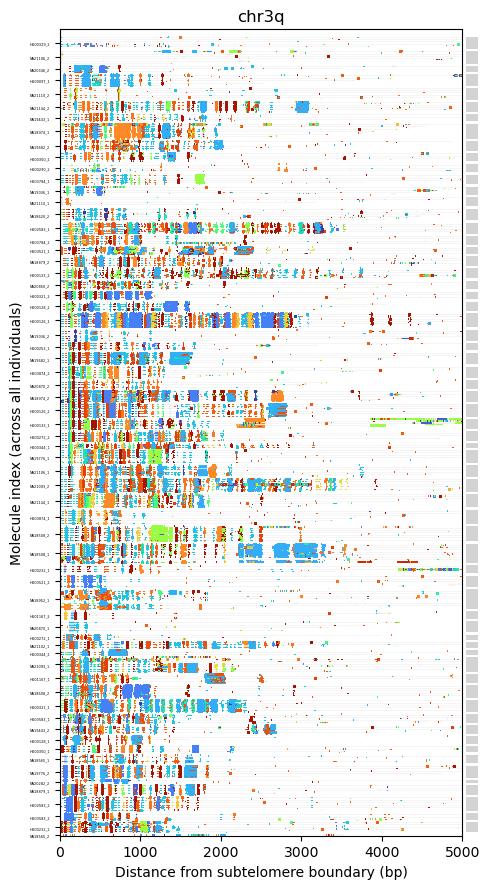

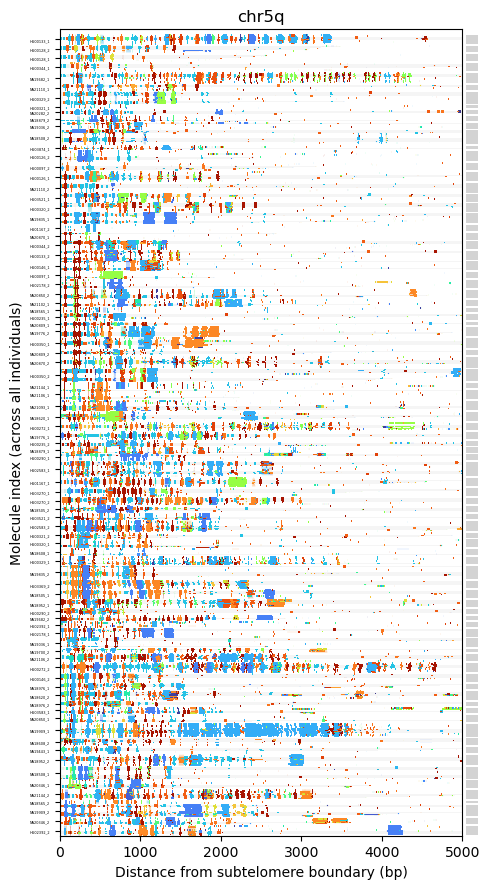

In [16]:
# Plot TVRs along single molecules used in 
# Fig1B,D S3, S4D
plotTVRs(ont_hprc_tsvs,'chr3q',similarity_df_ont,cmgr=cmgr,min_tvr_size=1)

plotTVRs(ont_hprc_tsvs,'chr5q',similarity_df_ont,cmgr=cmgr,min_tvr_size=1)

In [40]:
# PLOT COMPARISSONS BETWEEN ONT AND PACBIO DATA


def subset_by_dominant_chrom_assignment(df, chrom_end):
    """
    If multiple chrom_assignment values match chrom_end,
    select the one with the most rows.
    """
    sub = df[df["chrom_assignment"] == chrom_end]
    if len(sub) == 0:
        return sub

    # Count rows per chrom_assignment
    counts = sub["chrom_assignment"].value_counts()

    # Select the dominant chrom_assignment
    dominant = counts.idxmax()

    return df[df["chrom_assignment"] == dominant].copy()

def plotTVRs_two_tech_one_chrom(
    ont_df,
    pb_df,
    chrom_end,
    dist_bp=4_000,
    figsize=(6, 6),
    spacing_between_mols=2,
    spacing_between_techs=8,
    cmgr=None,
    min_reads_per_tech=10,
    min_tvr_size=1,
    max_tvr_size=300,
    k=6,                 # k-mer chunk used for coloring
    out_name=None,hap=1
):
    """
    Plot TVR-colored segments for one chrom (chrom_end) for ONT + PB dataframes.
    Only plots if BOTH technologies have >= min_reads_per_tech molecules for that chrom.
    """

    assert cmgr is not None, "Pass  cmgr (color manager) that implements cmgr.color_rgba(kmer)."

    # --- subset by chrom (NOT chrom_assignment) ---
    ont_tmp = subset_by_dominant_chrom_assignment(ont_df, chrom_end)
    pb_tmp  = subset_by_dominant_chrom_assignment(pb_df, chrom_end)

    # --- NEW: haplotype filter (minimal) ---
    if hap in (1, 2):
        tag = f"#{hap}#"
        pb_tmp = pb_tmp[pb_tmp["chrom"].astype(str).str.contains(tag, regex=False)]
        ont_tmp = ont_tmp[ont_tmp["chrom"].astype(str).str.contains(tag, regex=False)]
    # optional: if you want to restrict to molecules that actually have teloseq/tvr
    ont_tmp = ont_tmp[ont_tmp["teloseq"].astype(str).str.len() > 0]
    pb_tmp  = pb_tmp[pb_tmp["teloseq"].astype(str).str.len() > 0]
    
    
    
    # require min reads in BOTH techs
    if (len(ont_tmp) < min_reads_per_tech) or (len(pb_tmp) < min_reads_per_tech):
        print(f"[skip] {chrom_end}: ONT n={len(ont_tmp)}, PB n={len(pb_tmp)} (need >= {min_reads_per_tech} each)")
        return

    fig, ax = plt.subplots(figsize=figsize)
    canonical_gray = "whitesmoke"
    y_offset = 0

    def draw_rows(df, tech_label, y_offset):
        # sort molecules by span (like you were doing within grouped)
        # use centered_query_end if present, else fall back to teloseq length
        if "centered_query_end" in df.columns:
            spans = df["centered_query_end"].astype(float)
        else:
            spans = df["teloseq"].astype(str).str.len().astype(float)

        df = df.assign(_span=spans).sort_values("_span", ascending=True)

        # label for tech block
        ax.text(
            0, y_offset + 1.5,
            f"{tech_label} (n={len(df)})",
            ha="left", va="bottom", fontsize=8
        )
        y_offset += 4

        for row in df.itertuples(index=False):
            qe = int(getattr(row, "centered_query_end", dist_bp))
            teloseq = getattr(row, "teloseq", "")
            tvr = getattr(row, "tvr", None)

            if not isinstance(teloseq, str) or len(teloseq) == 0:
                continue
            if tvr is None:
                continue

            L = min(int(qe), dist_bp, len(teloseq))
            if L <= 0:
                continue

            # ensure tvr is array-like of shape (n,2)
            tvr_arr = np.asarray(tvr)
            if tvr_arr.size == 0:
                y_offset += spacing_between_mols
                continue
            if tvr_arr.ndim != 2 or tvr_arr.shape[1] < 2:
                # malformed tvr
                y_offset += spacing_between_mols
                continue

            segments_by_color = {}

            # iterate TVR blocks
            for start, length in zip(tvr_arr[:, 0], tvr_arr[:, 1]):
                start = int(start)
                length = int(length)

                if length < min_tvr_size or length > max_tvr_size:
                    continue
                if start >= dist_bp or start >= L:
                    continue

                end = min(start + length, L)
                pos = start

                while pos < end:
                    frag_end = min(pos + k, end)
                    frag = teloseq[pos:frag_end]
                    if not frag:
                        break

                    color = cmgr.color_rgba(frag)

                    # merge adjacent identical fragments using stride = current frag length
                    run_end = frag_end
                    stride = frag_end - pos
                    while run_end + stride <= end and teloseq[run_end:run_end + stride] == frag:
                        run_end += stride

                    segments_by_color.setdefault(color, []).append((pos, run_end - pos))
                    pos = run_end

            # skip empty
            if len(segments_by_color) == 0:
                y_offset += spacing_between_mols
                continue

            # canonical background
            ax.add_patch(Rectangle(
                (0, y_offset - 0.4), L, 0.8,
                color=canonical_gray, lw=0, antialiased=False, alpha=1
            ))

            # TVR colored segments
            for color, spans in segments_by_color.items():
                coll = BrokenBarHCollection(
                    xranges=spans,
                    yrange=(y_offset - 0.4, 0.8),
                    facecolors=[color],
                    edgecolors=[color],
                    linewidths=0.1,
                    antialiased=False,
                )
                ax.add_collection(coll)

            y_offset += spacing_between_mols

        return y_offset

    # --- draw ONT then PB ---
    y_offset = draw_rows(ont_tmp, "ONT", y_offset)
    y_offset += spacing_between_techs
    y_offset = draw_rows(pb_tmp, "PacBio", y_offset)

    # --- final formatting ---
    ax.set_xlim(0, dist_bp)
    ax.set_ylim(-2, y_offset + 10)
    ax.set_xlabel("Distance from subtelomere boundary (bp)")
    ax.set_ylabel("Molecule index")
    ax.set_title(f"{ont_tmp.chrom.iloc[0]} {chrom_end}")

    ax.set_rasterization_zorder(1)
    ax.tick_params(axis='both', which='both', bottom=True, left=True, labelbottom=True, labelleft=False)

    plt.tight_layout()
    if out_name:
        plt.savefig(out_name, dpi=350)
        plt.show()
        plt.close(fig)
    else:
        plt.show()
    seq  = ont_tmp.teloseq.iloc[0][:250]
    tvrs = ont_tmp.tvr.iloc[0]

    mask = np.zeros(len(seq), dtype=bool)
    for s, w in tvrs:
        s, e = int(s), int(s + w)
        mask[max(s, 0):min(e, len(seq))] = True

    out, i = [], 0
    while i < len(seq):
        j = i
        while j < len(seq) and mask[j] == mask[i]:
            j += 1
        out.append(f"**{seq[i:j]}**" if mask[i] else seq[i:j])
        i = j

    print("".join(out))

# Examples of the TVR Calls between the two technologies in Fig 1C + S4A
    
ends_to_plot_compare_ont_to_pacbio =  [('chr4p','NA19700',1),
                                       ('chr7q', 'HG03874',2),
                                      ('chr2q', 'NA19700',2),
                                      ('chr20p', 'NA20870',2)]


for end in ends_to_plot_compare_ont_to_pacbio:
    ont_sample = ont_hprc_tsvs[end[1]]
    pb_sample  = pb_hprc_tsvs[end[1]]
    val = plotTVRs_two_tech_one_chrom(
        ont_df=ont_sample,
        pb_df=pb_sample,
        chrom_end=end[0],
        cmgr=cmgr,
        min_reads_per_tech=5,
        dist_bp=5_000,hap=end[2],min_tvr_size=12,
        out_name=None
    )


100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 51/51 [00:02<00:00, 19.06it/s]


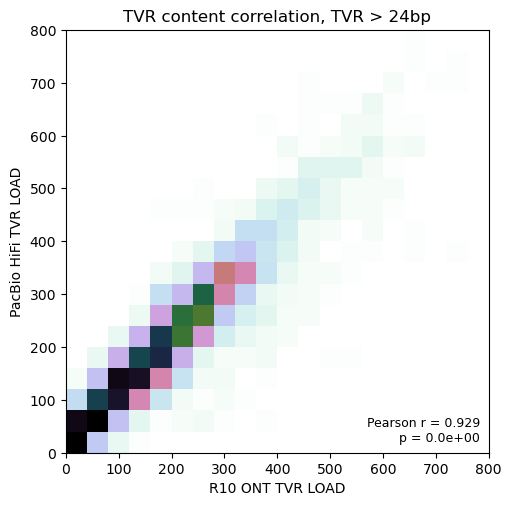

In [52]:
# PLOT the overall TVR load between ONT and PacBio for 1C

from scipy.stats import pearsonr

def tvr_load_per_read(tvrs, min_tvr_bp=0):
    return sum(w for _, w in tvrs if w >= min_tvr_bp)

def matchSamplesTVRLoad(ont_tsvs, pb_tsvs, min_tvr_bp=0):
    ont_load = []
    pb_load  = []

    for individual in tqdm(ont_tsvs.keys() & pb_tsvs.keys()):
        ont_sample = ont_tsvs[individual]
        pb_sample  = pb_tsvs[individual]
        pb_sample = pb_sample[pb_sample.centered_query_end > 1_000]
        ont_sample = ont_sample[ont_sample.centered_query_end > 1_000]

        # precompute per-read TVR load (fast, single pass)
        ont_sample = ont_sample.copy()
        pb_sample  = pb_sample.copy()
        ont_sample["tvr_load"] = [
            tvr_load_per_read(tvrs, min_tvr_bp) for tvrs in ont_sample.tvr
        ]
        pb_sample["tvr_load"] = [
            tvr_load_per_read(tvrs, min_tvr_bp) for tvrs in pb_sample.tvr
        ]

        for chrom, ont_group in ont_sample.groupby("chrom"):
            pb_group = pb_sample[pb_sample.chrom == chrom]

            if len(ont_group) < 10 or len(pb_group) < 5:
                continue

            ont_load.append(ont_group.tvr_load.mean())
            pb_load.append(pb_group.tvr_load.mean())

    return np.array(ont_load), np.array(pb_load)

# all TVRs

# only TVRs ≥ 24 bp
ont_load, pb_load = matchSamplesTVRLoad(
    ont_hprc_tsvs, pb_hprc_tsvs, min_tvr_bp=24
)  

plt.figure(figsize=(5, 5))
plt.hist2d(
    ont_load,
    pb_load,
    bins= 20,
    range=[[0, 800], [0, 800]],
    cmap="cubehelix_r",
    vmax=100
    
)

plt.gca().set_aspect("equal", adjustable="box")

plt.tight_layout()

r, p = pearsonr(ont_load, pb_load)

plt.gca().set_aspect("equal", adjustable="box")
plt.xlabel("R10 ONT TVR LOAD")
plt.ylabel("PacBio HiFi TVR LOAD")
plt.title("TVR content correlation, TVR > 24bp")

ax = plt.gca()
ax.text(
    0.98, 0.02,
    f"Pearson r = {r:.3f}\np = {p:.1e}",
    transform=ax.transAxes,
    ha="right", va="bottom",
    fontsize=9,
    bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="none", alpha=0.7),
)

plt.show()

Total PacBio TVR blocks: 17695775
Total ONT TVR blocks: 4079482


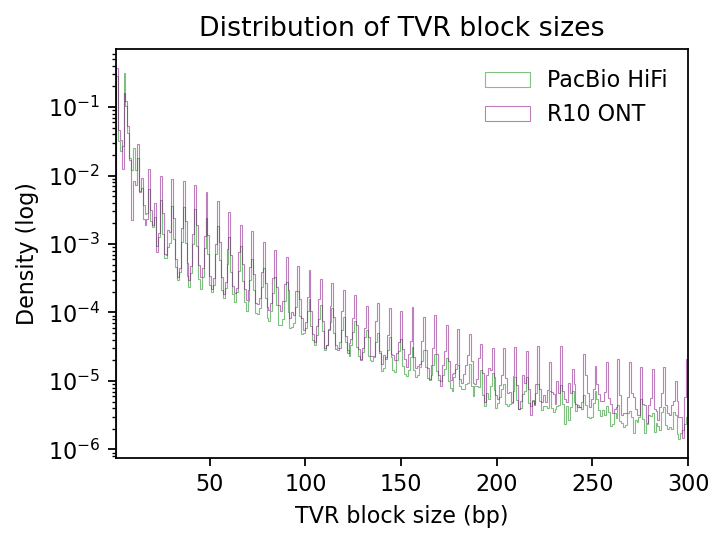

In [57]:
def extract_tvr_sizes(hprc_dict, dataset_name=""):
    """
    Parses the 'tvr' column from a dictionary of HPRC DataFrames 
    and extracts all TVR block sizes into a single numpy array.
    """
    tvr_sizes = []

    for individual, df in hprc_dict.items():
        # If tvr column is string-encoded, parse once
        if df["tvr"].dtype == object:
            sample_val = df["tvr"].dropna().iloc[0]
            if isinstance(sample_val, str):
                df = df.copy()
                df["tvr"] = df["tvr"].apply(
                    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
                )
                
        for tvr_list in df["tvr"].dropna():
            if tvr_list is None or len(tvr_list) == 0:
                continue
            for pos, length in tvr_list:
                tvr_sizes.append(length)
                
    tvr_sizes_arr = np.asarray(tvr_sizes)
    print(f"Total {dataset_name} TVR blocks:", len(tvr_sizes_arr))
    
    return tvr_sizes_arr

# --- 1. Extract the data using the new function ---
pb_tvr_sizes = extract_tvr_sizes(pb_hprc_tsvs, "PacBio")
ont_tvr_sizes = extract_tvr_sizes(ont_hprc_tsvs, "ONT")


# --- 2. Plot the results ---
plt.figure(figsize=(4.5, 3.5), dpi=160)

plt.hist(pb_tvr_sizes, bins=300, log=True, density=True, histtype='step', alpha=0.5, ec='green', label='PacBio HiFi', lw=0.5)
plt.hist(ont_tvr_sizes, bins=300, log=True, density=True, histtype='step', alpha=0.5, ec='purple', label='R10 ONT', lw=0.5)

plt.xlabel("TVR block size (bp)")
plt.ylabel("Density (log)")
plt.title("Distribution of TVR block sizes")

plt.tight_layout()
plt.xlim(1, 300)
plt.legend(frameon=False)

# plt.savefig('v2/tvr_block_size_pb_v_ont_histogram.pdf',dpi=300)
plt.show()

Processing PacBio HiFi: 100%|███████████████████████████████████████████████████████████████████████| 212/212 [00:43<00:00,  4.85it/s]


PacBio HiFi TVR proportion: first 1kb = 51.63%, first 5kb = 96.97% (min TVR length 24, min telo length 1000)


Processing ONT: 100%|█████████████████████████████████████████████████████████████████████████████████| 51/51 [00:11<00:00,  4.44it/s]


ONT TVR proportion: first 1kb = 49.72%, first 5kb = 94.50% (min TVR length 24, min telo length 1000)


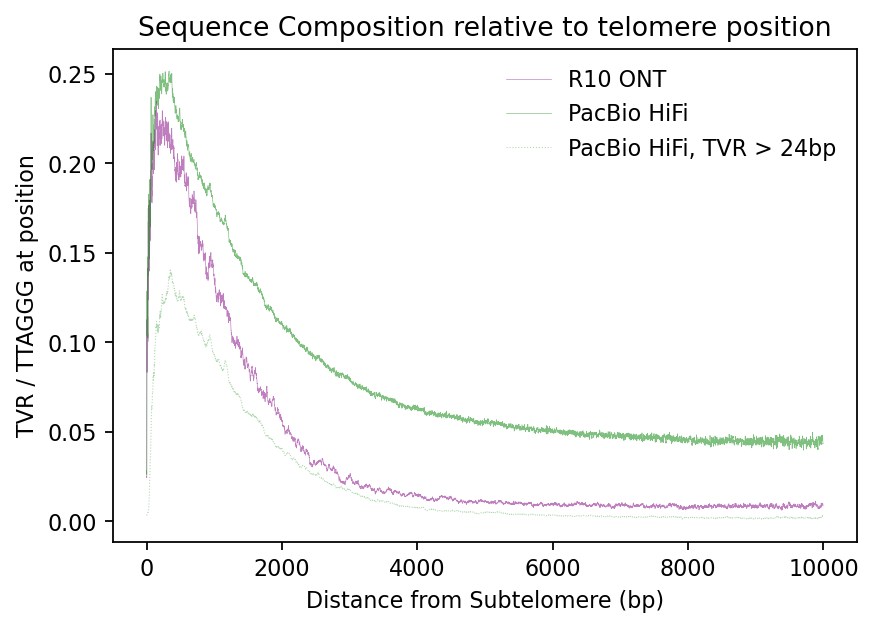

In [59]:
def nanpad_mean(traces):
    if not traces:
        return None
    lengths = np.fromiter((len(x) for x in traces), dtype=int)
    max_len = lengths.max()
    stack = np.full((len(traces), max_len), np.nan, dtype=float)
    for i, arr in enumerate(traces):
        stack[i, :len(arr)] = arr
    return np.nanmean(stack, axis=0)

def compute_tvr_composition(hprc_dict, dataset_name, min_cov=5, min_len=1000, tvr_min_bp=24):
    """
    Computes TVR density arrays and returns mean traces.
    Tracks TVR proportion in the first 1kb and 5kb.
    """
    all_tvr_comp = []
    all_tvr_comp_24 = []
    chrom_assignment_for_tvr = []
    chrom_assignment_for_tvr_24 = []

    tvr24_total_bp = 0
    tvr24_1kb_bp = 0
    tvr24_5kb_bp = 0

    for individual, df in tqdm(hprc_dict.items(), desc=f"Processing {dataset_name}"):
        for chrom in df.chrom.unique():
            chrom_df = df[df.chrom == chrom]
            L = int(chrom_df.centered_query_end.max())

            den_diff = np.zeros(L + 1, dtype=np.int32)
            num_diff = np.zeros(L + 1, dtype=np.int32)
            num24_diff = np.zeros(L + 1, dtype=np.int32)

            ends = chrom_df.centered_query_end.astype(np.int64).to_numpy()
            den_diff[0] += len(ends)
            np.add.at(den_diff, ends, -1)

            for tvrs in chrom_df.tvr:
                for s, w in tvrs:
                    s, w = int(s), int(w)
                    e = s + w
                    if e <= 0 or s >= L:
                        continue
                    s = max(s, 0); e = min(e, L)

                    num_diff[s] += 1
                    num_diff[e] -= 1

                    if w >= tvr_min_bp:
                        num24_diff[s] += 1
                        num24_diff[e] -= 1

                        # ---- accumulate TVR>=24bp bases in first 1kb and 5kb ----
                        tvr24_total_bp += (e - s)
                        tvr24_1kb_bp += max(0, min(e, 1000) - max(s, 0))
                        tvr24_5kb_bp += max(0, min(e, 5000) - max(s, 0))

            denom = np.cumsum(den_diff[:-1]).astype(float)
            num   = np.cumsum(num_diff[:-1]).astype(float)
            num24 = np.cumsum(num24_diff[:-1]).astype(float)

            comp   = np.divide(num,   denom, out=np.full(L, np.nan), where=denom > min_cov)
            comp24 = np.divide(num24, denom, out=np.full(L, np.nan), where=denom > min_cov)

            comp   = comp[~np.isnan(comp)]
            comp24 = comp24[~np.isnan(comp24)]

            if len(comp) > min_len:
                all_tvr_comp.append(comp)
                if "chrom_assignment" in chrom_df.columns:
                    chrom_assignment_for_tvr.append(chrom_df["chrom_assignment"].iloc[0])

            if len(comp24) > min_len:
                all_tvr_comp_24.append(comp24)
                if "chrom_assignment" in chrom_df.columns:
                    chrom_assignment_for_tvr_24.append(chrom_df["chrom_assignment"].iloc[0])

    mean_trace    = nanpad_mean(all_tvr_comp)
    mean_trace_24 = nanpad_mean(all_tvr_comp_24)

    # Calculate proportions
    pct_tvr24_1kb = (100.0 * tvr24_1kb_bp / tvr24_total_bp) if tvr24_total_bp else np.nan
    pct_tvr24_5kb = (100.0 * tvr24_5kb_bp / tvr24_total_bp) if tvr24_total_bp else np.nan

    print(f'{dataset_name} TVR proportion: first 1kb = {pct_tvr24_1kb:.2f}%, first 5kb = {pct_tvr24_5kb:.2f}% (min TVR length {tvr_min_bp}, min telo length {min_len})')

    return {
        "mean_trace": mean_trace,
        "mean_trace_24": mean_trace_24,
        "chrom_assignments": chrom_assignment_for_tvr,
        "chrom_assignments_24": chrom_assignment_for_tvr_24
    }

# --- 1. Set Parameters ---
MIN_COV = 5
MIN_LEN = 1000
TVR_MIN_BP = 24

# --- 2. Process Data ---
pb_results = compute_tvr_composition(pb_hprc_tsvs, "PacBio HiFi", MIN_COV, MIN_LEN, TVR_MIN_BP)
ont_results = compute_tvr_composition(ont_hprc_tsvs, "ONT", MIN_COV, MIN_LEN, TVR_MIN_BP)

# --- 3. Plot ---
plt.figure(figsize=(6, 4), dpi=160)

# Unpack the traces we need
ont_mean_trace = ont_results["mean_trace"]
pb_mean_trace = pb_results["mean_trace"]
pb_mean_trace_24 = pb_results["mean_trace_24"]

if ont_mean_trace is not None:
    plt.plot(ont_mean_trace[5:10_000], c='purple', alpha=0.5, lw=0.3, label='R10 ONT')
if pb_mean_trace is not None:
    plt.plot(pb_mean_trace[5:10_000], c='green', alpha=0.5, lw=0.3, label='PacBio HiFi')
if pb_mean_trace_24 is not None:
    plt.plot(pb_mean_trace_24[5:10_000], c='green', alpha=0.3, ls='dotted', lw=0.5, label='PacBio HiFi, TVR > 24bp')

plt.xlabel('Distance from Subtelomere (bp)')
plt.ylabel('TVR / TTAGGG at position')
plt.title('Sequence Composition relative to telomere position')
plt.legend(frameon=False)

# plt.savefig('v2/tvr_proportion_relative_to_position_pb_v_ont_histogram.pdf',dpi=300)
plt.show()

In [69]:
from nltk.util import ngrams
def hprc_best_k_coverage(hprc_dict, dataset_name="Data", ks=(3,4,5,6,7,8,9), 
                         min_tvr_size=24, max_tvr_size=300,
                         teloseq_col="teloseq", tvr_col="tvr", ignore_char="N"):
    """
    For a dictionary of HPRC TSVs, return {k: array_of_percents} where each percent is:
      (max over kmers of union-of-occurrence coverage of that kmer) / TVR length * 100.
    """
    ks = tuple(int(k) for k in ks)
    global_per_k = {k: [] for k in ks}

    for individual, df in tqdm(hprc_dict.items(), desc=f"Calculating k-mer coverage for {dataset_name}"):
        for _, r in df.iterrows():
            seq = (r.get(teloseq_col, "") or "").upper()
            L   = len(seq)
            tb  = r.get(tvr_col, None)
            
            if L == 0 or tb is None or len(tb) == 0:
                continue

            arr = np.array(tb, dtype=int).reshape(-1, 2)
            
            for s, sz in arr:
                if sz <= 0 or s < 0 or s >= L:
                    continue
                if sz < min_tvr_size:
                    continue
                if (max_tvr_size is not None) and (sz > max_tvr_size):
                    continue

                e  = min(L, s + sz)
                tv = seq[s:e]
                n  = len(tv)
                if n <= 0:
                    continue

                for k in ks:
                    if k <= 0 or n < k:
                        global_per_k[k].append(0.0)
                        continue

                    starts_by_kmer = {}
                    for idx, g in enumerate(ngrams(tv, k)):
                        if ignore_char and (ignore_char in g):
                            continue
                        km = ''.join(g)
                        if km in starts_by_kmer:
                            starts_by_kmer[km].append(idx)
                        else:
                            starts_by_kmer[km] = [idx]

                    if not starts_by_kmer:
                        global_per_k[k].append(0.0)
                        continue

                    best_cover = 0
                    for km, starts in starts_by_kmer.items():
                        if not starts:
                            continue
                        mask = np.zeros(n, dtype=bool)
                        for i0 in starts:
                            i1 = i0 + k
                            if i0 < n:
                                mask[i0:min(i1, n)] = True
                        cov = int(mask.sum())
                        if cov > best_cover:
                            best_cover = cov

                    global_per_k[k].append((best_cover / float(n)) * 100.0)

    return {k: np.array(vals) for k, vals in global_per_k.items()}


# run
ks_to_test = (3,4,5,6,7,8,9)

ont_results = hprc_best_k_coverage(
    hprc_dict=ont_hprc_tsvs, 
    dataset_name="ONT",
    ks=ks_to_test, 
    min_tvr_size=24, 
    max_tvr_size=300
)



Calculating k-mer coverage for ONT: 100%|█████████████████████████████████████████████████████████████| 51/51 [01:53<00:00,  2.22s/it]


comparing k = 6 to 5: p = 0.0, mann-whitney-u statistic: 117096722101.0
comparing k = 6 to 7: p = 0.0, mann-whitney-u statistic: 103692181191.5
comparing k = 6 to 4: p = 0.0, mann-whitney-u statistic: 130902156453.5
comparing k = 6 to 8: p = 0.0, mann-whitney-u statistic: 106316312271.5
comparing k = 6 to 3: p = 0.0, mann-whitney-u statistic: 135500049508.0
comparing k = 6 to 9: p = 0.0, mann-whitney-u statistic: 103512449237.0


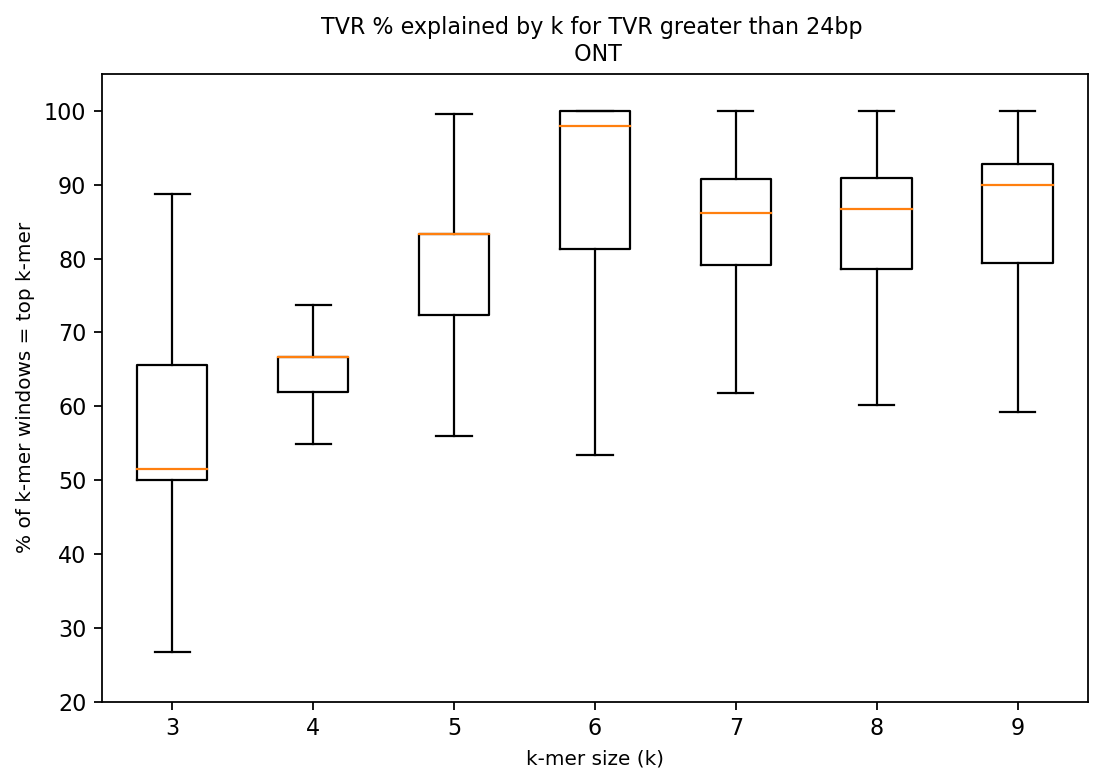

In [71]:
# plotting
plt.figure(figsize=(7, 5), dpi=160)

for_plotting = [ont_results[k] for k in ks_to_test]

plt.boxplot(for_plotting, positions=ks_to_test, sym="")
plt.title("TVR % explained by k for TVR greater than 24bp \n ONT", fontsize=10)
plt.ylabel("% of k-mer windows = top k-mer", fontsize=9)
plt.xlabel("k-mer size (k)", fontsize=9)

# annotation
data_6 = ont_results[6]

y_base = 105 
y_step = 8

other_ks = [5, 7, 4, 8, 3, 9]

for i, k in enumerate(other_ks):
    data_k = ont_results[k]
    
    # Calculate p-value
    stat, p_val = mannwhitneyu(data_6, data_k, alternative='two-sided')
    print(f'comparing k = 6 to {k}: p = {p_val}, mann-whitney-u statistic: {stat}')
    # Coordinates for the bracket


# Adjust y-limit to comfortably fit the boxplots and all the new annotation brackets
max_y_needed = y_base + (len(other_ks) * y_step) + 5
plt.ylim(20, 105)

plt.savefig('best_described_tvr_gt24bp_ont_04022026.pdf', dpi=300)
plt.tight_layout()
plt.show()

Counting k-mers: 100%|██████████████████████████████████████████████████████████████████████████████| 212/212 [00:24<00:00,  8.66it/s]


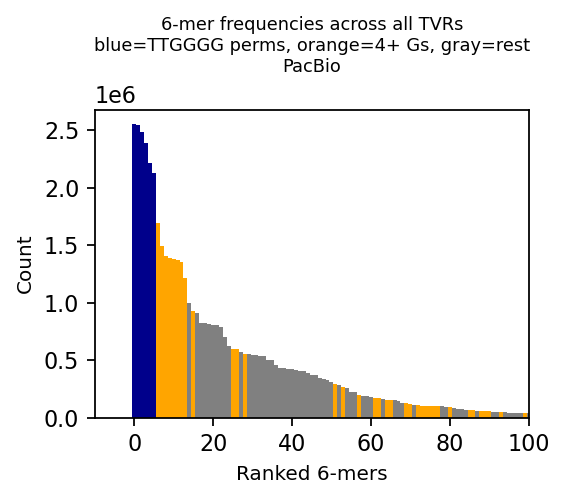

Counting k-mers: 100%|████████████████████████████████████████████████████████████████████████████████| 51/51 [00:08<00:00,  5.85it/s]


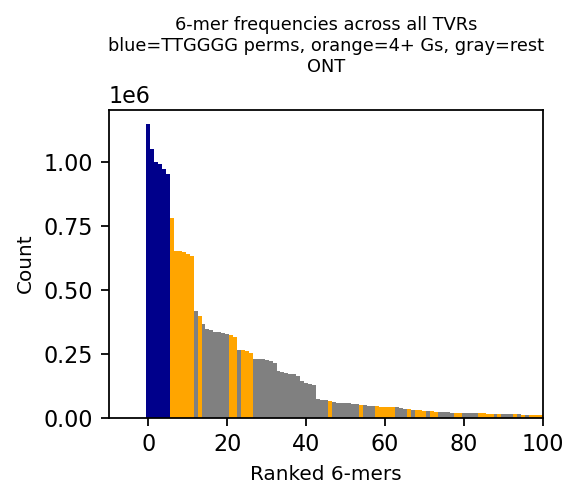

In [83]:
def plot_tvr_kmers_all(all_tsvs, teloseq_col="teloseq", tvr_col="tvr", 
                       k=6, min_tvr_size=6, 
                       title_add=None, save_name=None):
    """
    Extracts and counts k-mers from tvrs  across multiple datasets,
    then plots a ranked bar chart of their frequencies.

    """
    
    kmer_counts = Counter()

    for tsv in tqdm(all_tsvs.values(), desc="Counting k-mers"):
        for _, row in tsv.iterrows():
            seq = (row.get(teloseq_col, "") or "").upper()
            L = len(seq)
            
            # skip if sequence is too short to even contain one k-mer
            if L < k:
                continue

            tvr_blocks = row.get(tvr_col, None)

            
            # parse the start positions and sizes of the TVR blocks
            arr = np.array(tvr_blocks, dtype=int).reshape(-1, 2)
            
            for s, size in arr:
                if size > min_tvr_size:
                    start = max(0, s) 
                    end = min(L, s + size) 
                    
                    for i in range(start, end - k + 1):
                        kmer = seq[i:i+k]
                        if "N" not in kmer:
                            kmer_counts[kmer] += 1

    sorted_kmers = kmer_counts.most_common()
    
    x = np.arange(len(sorted_kmers))
    y = [count for _, count in sorted_kmers]
    
    blue_set = rotations("TTGGGG")  
    colors = []
    
    for kmer, _ in sorted_kmers:
        if kmer in blue_set:
            colors.append("darkblue")
        elif kmer.count("G") >= 4:
            colors.append("orange")
        else:
            colors.append("gray")

    plt.figure(figsize=(3.5, 2.5), dpi=160)
    
    plt.bar(x, y, width=1.0, color=colors, align='center', alpha=1, linewidth=0)

    plt.xlabel(f"Ranked {k}-mers", fontsize=9)
    plt.ylabel("Count", fontsize=9)
    plt.xlim(-10, 100) # Zoom in on the top 100 kmers

    base_title = f"{k}-mer frequencies across all TVRs\nblue=TTGGGG perms, orange=4+ Gs, gray=rest"
    if title_add:
        plt.title(f"{base_title}\n{title_add}", fontsize=8)
    else:
        plt.title(base_title, fontsize=8)
            
    if save_name:
        plt.savefig(save_name, dpi=350)
        
    plt.show()

    return dict(sorted_kmers)

# --- Execution ---
sorted_kmers_pb = plot_tvr_kmers_all(pb_hprc_tsvs, title_add='PacBio', save_name='pacbio_raw_count_kmer_freqs_min_tvr_size_6_no_edge_04022026.pdf')
sorted_kmers_ont = plot_tvr_kmers_all(ont_hprc_tsvs, title_add='ONT', save_name='ont_raw_count_kmer_freqs_min_tvr_size_6_no_edge_04022026.pdf')





In [81]:
def print_top_kmers(kmer_dict, dataset_name="Dataset", top_n=20):
    """
    Prints the top N most frequent k-mers from a sorted dictionary.
    """
    print(f"--- Top {top_n} {len(next(iter(kmer_dict)))}-mers for {dataset_name} ---")
    
    # Slice the first top_n items from the dictionary
    top_items = list(kmer_dict.items())[:top_n]
    
    for rank, (kmer, count) in enumerate(top_items, start=1):
        # The >2 formatting aligns the single and double-digit ranks nicely
        # The :, formatting adds commas to large numbers (e.g. 10,000)
        print(f"{rank:>2}. {kmer}: {count:,}")
        
    print("-" * 35 + "\n")

# --- Execution ---
print_top_kmers(sorted_kmers_pb, dataset_name="PacBio", top_n=20)
print_top_kmers(sorted_kmers_ont, dataset_name="ONT", top_n=20)

--- Top 20 6-mers for PacBio ---
 1. GTTGGG: 2,551,763
 2. TTGGGG: 2,543,176
 3. GGTTGG: 2,487,356
 4. GGGTTG: 2,388,558
 5. TGGGGT: 2,212,611
 6. GGGGTT: 2,128,093
 7. TGAGGG: 1,693,016
 8. GTAGGG: 1,494,982
 9. GAGGGT: 1,404,138
10. GTGAGG: 1,391,785
11. GGTGAG: 1,377,660
12. AGGGTG: 1,366,387
13. GGGTGA: 1,355,430
14. GGTAGG: 1,216,527
15. TTCGGG: 996,691
16. GGGTAG: 925,693
17. TAAGGG: 911,692
18. TTAAGG: 822,424
19. GTTCGG: 819,115
20. TCGGGT: 817,043
-----------------------------------

--- Top 20 6-mers for ONT ---
 1. TTGGGG: 1,148,788
 2. GTTGGG: 1,053,674
 3. GGTTGG: 999,006
 4. GGGTTG: 994,661
 5. TGGGGT: 972,729
 6. GGGGTT: 952,257
 7. TGAGGG: 783,266
 8. GTGAGG: 653,071
 9. GAGGGT: 651,246
10. GGTGAG: 649,181
11. GGGTGA: 639,884
12. AGGGTG: 633,137
13. TTCGGG: 418,247
14. GTAGGG: 398,378
15. TAAGGG: 364,974
16. TTAAGG: 346,335
17. TCGGGT: 342,018
18. GGGTTC: 335,845
19. GTTCGG: 334,168
20. GGTTCG: 331,320
-----------------------------------



In [91]:
# FIG 1 G



from collections import defaultdict

def make_topk_color_lookup(kept_kmers, cmgr, cmap="turbo", cmap_min=0.05, cmap_max=0.95):
    """
    Assign maximally separated colors to the provided kmers by sampling the colormap evenly.
    Returns dict: kmer -> rgba
    """
    cmap_obj = plt.get_cmap(cmap)

    n = len(kept_kmers)
    if n == 0:
        return {}

    # evenly spaced positions in [cmap_min, cmap_max]
    ts = np.linspace(cmap_min, cmap_max, n)

    def _canon(km):
        km = str(km).upper()
        return cmgr._key(km) if hasattr(cmgr, "_key") else km

    kept_keys = [_canon(km) for km in kept_kmers]

    return {key: cmap_obj(t) for key, t in zip(kept_keys, ts)}


def plot_tvr_kmer_composition_stacked_subset_color(
    all_tsvs,
    dist_bp=5_000,
    min_tvr_size=1,
    max_tvr_size=1_000,
    top_n_kmers=10,          # keep plot readable; remainder goes to "OTHER"
    normalize=True,          # True => fractions per chrom_assignment
    figsize=(6, 3),
    out_name=None,k=6
):
    """
    One stacked bar per chrom_assignment. Each stack = k-mer composition within TVR segments.
    """

    # --------- accumulate kmer bp counts per chrom_assignment ----------
    per_end = defaultdict(lambda: defaultdict(int))  # chrom_assignment -> kmer -> bp
    ends_seen = set()
    reads_per_end = defaultdict(int)   # chrom_assignment -> # rows processed


    for label,tsv in tqdm(all_tsvs.items()):
#         print(tsv)
        if "chrom_assignment" not in tsv.columns:
            continue
        if "teloseq" not in tsv.columns or "tvr" not in tsv.columns:
            continue

        for row in tsv.itertuples():
            chrom_end = getattr(row, "chrom_assignment", None)
            if chrom_end is None or (isinstance(chrom_end, float) and np.isnan(chrom_end)):
                continue
            if chrom_end not in canonical_arms[:-2]:
                continue
            chrom_end = str(chrom_end)
            ends_seen.add(chrom_end)

            teloseq = getattr(row, "teloseq", None)
            tvr = getattr(row, "tvr", None)
            if teloseq is None or tvr is None:
                continue

            try:
                starts = np.asarray(tvr)[:, 0].astype(int)
                lens   = np.asarray(tvr)[:, 1].astype(int)
            except Exception:
                continue
            
            reads_per_end[chrom_end] += 1

            for start, length in zip(starts, lens):
                
                if length < min_tvr_size or length > max_tvr_size:
                    continue
                if start >= dist_bp:
                    continue

                end = min(start + length, dist_bp)
                pos = int(start)


                while pos < end:
                    frag_len = min(k, end - pos)  
                    if frag_len != k:
                        break  # ignore trailing short fragment so only true k-mers contribute
                    frag = teloseq[pos:pos + k].upper()
                    if not frag:
                        break
                    per_end[chrom_end][frag] += frag_len
                    pos += frag_len

    # --------- normalize kmer bp counts by # reads processed per chrom_assignment ----------
    for chrom_end, kmer_dict in per_end.items():
        n = reads_per_end.get(chrom_end, 0)
        if n > 0:
            for km in list(kmer_dict.keys()):
                kmer_dict[km] /= n   # now "bp per read"

    chrom_ends = sorted(list(ends_seen), key=_natkey)
    if not chrom_ends:
        raise ValueError("No chrom_assignment entries found with usable teloseq/tvr data.")

    # --------- choose kmers to display (global top_n), aggregate others ----------
    global_counts = defaultdict(int)
    for ce in chrom_ends:
        for km, bp in per_end[ce].items():
            global_counts[km] += bp

    kmers_sorted = sorted(global_counts.items(), key=lambda x: x[1], reverse=True)
    kept_kmers = [km for km, _ in kmers_sorted[:top_n_kmers]]

    # build matrix [n_kmers(+other) x n_chrom_ends]
    labels = kept_kmers + (["OTHER"] if len(kmers_sorted) > top_n_kmers else [])
    M = np.zeros((len(labels), len(chrom_ends)), dtype=float)

    for j, ce in tqdm(enumerate(chrom_ends)):
        total = sum(per_end[ce].values())
        if total == 0:
            continue

        kept_sum = 0
        for i, km in enumerate(kept_kmers):
            v = per_end[ce].get(km, 0)
            M[i, j] = v
            kept_sum += v

        if "OTHER" in labels:
            M[len(labels) - 1, j] = max(0, total - kept_sum)

        if normalize:
            M[:, j] /= total

    # top-kmer colors: maximally separated (dict: canonical_kmer -> rgba)
    topk_color = make_topk_color_lookup(
        kept_kmers=kept_kmers,
        cmgr=cmgr,
        cmap="turbo",
        cmap_min=0.05,
        cmap_max=0.95
    )

    labels = kept_kmers + (["OTHER"] if len(kmers_sorted) > top_n_kmers else [])

    # build colors with a hard guarantee: every kept_kmer must exist
    colors = []
    for lab in labels:
        if lab == "OTHER":
            colors.append('whitesmoke')
            continue

        key = cmgr._key(str(lab).upper()) if hasattr(cmgr, "_key") else str(lab).upper()
        assert key in topk_color, f"Missing color for {lab} (canonical key={key})"
        colors.append(topk_color[key])

    tar_unique_chroms = defaultdict(set)
    for tsv in all_tsvs.values():
        if not {"chrom", "chrom_assignment", "tar_status"}.issubset(tsv.columns):
            continue
        tmp = tsv.loc[tsv["tar_status"] == True, ["chrom_assignment", "chrom"]].dropna()
        for ce, chrom in zip(tmp["chrom_assignment"].astype(str), tmp["chrom"].astype(str)):
            tar_unique_chroms[ce].add(chrom)

    tar_counts = {ce: len(s) for ce, s in tar_unique_chroms.items()}
    tar_score = np.array([tar_counts.get(ce, 0) for ce in chrom_ends], dtype=int)

    order = np.argsort(tar_score)[::-1]   # descending
    M = M[:, order]
    chrom_ends = [chrom_ends[i] for i in order]

    # --------- PLOT (define x/bottom AFTER sorting) ----------
    x = np.arange(len(chrom_ends))
    bottom = np.zeros(len(chrom_ends), dtype=float)

    plt.figure(figsize=figsize, dpi=150)
    for i, lab in enumerate(labels):
        plt.bar(
            x, M[i],
            bottom=bottom,
            label=lab,
            color=colors[i],
            edgecolor=colors[i],
            linewidth=0
        )
        bottom += M[i]

    plt.xticks(x, chrom_ends, rotation=90, fontsize=5)
    plt.xlabel("chrom_assignment")
    plt.ylabel("Fraction of TVR bp" if normalize else "TVR bp (summed)")
    plt.title(f"TVR k-mer composition per chrom_assignment (top {top_n_kmers}" +
              (", +OTHER" if "OTHER" in labels else "") + ")")
    plt.margins(x=0.01)
    plt.tight_layout()

    if out_name:
        plt.savefig(out_name, dpi=350, bbox_inches="tight")
        plt.show()
        plt.clf()
    else:
        plt.show()

100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 51/51 [00:02<00:00, 17.41it/s]
46it [00:00, 96180.45it/s]


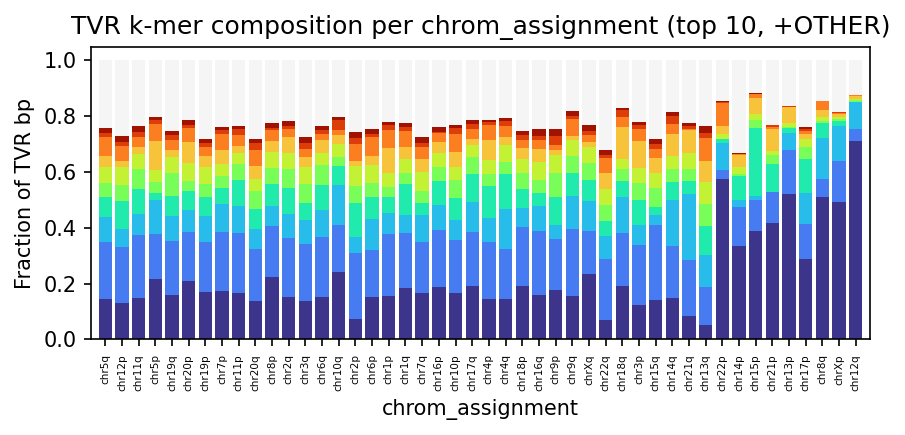

100%|███████████████████████████████████████████████████████████████████████████████████████████████| 212/212 [00:08<00:00, 25.13it/s]
46it [00:00, 104516.78it/s]


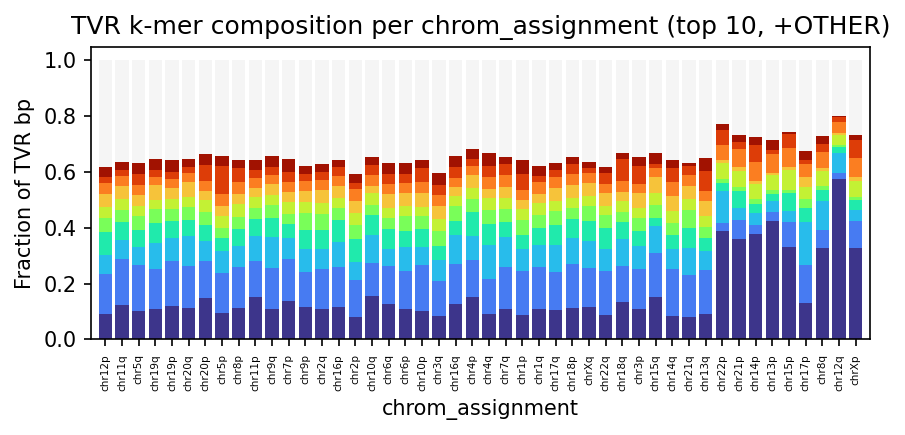

In [92]:
plot_tvr_kmer_composition_stacked_subset_color(ont_hprc_tsvs)
plot_tvr_kmer_composition_stacked_subset_color(pb_hprc_tsvs)


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 51/51 [00:09<00:00,  5.16it/s]


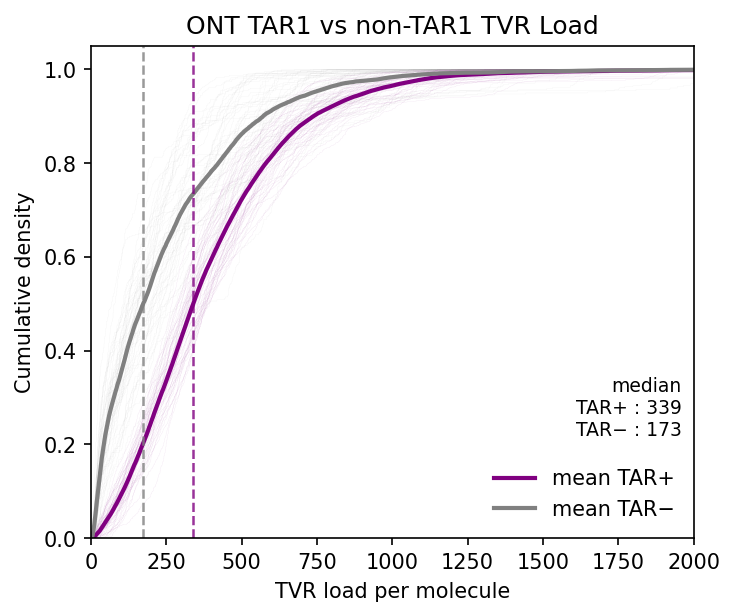

In [19]:
# fig 1H
def cdf_n50(x, cdf, q=0.5): # essentially median
    x = np.asarray(x)
    cdf = np.asarray(cdf)

    m = np.isfinite(x) & np.isfinite(cdf)
    x = x[m]
    cdf = cdf[m]
    if x.size == 0:
        return np.nan

    # ensure monotone (mean CDF can wiggle slightly)
    cdf = np.maximum.accumulate(cdf)

    if cdf[-1] < q:
        return x[-1]
    if cdf[0] >= q:
        return x[0]

    return float(np.interp(q, cdf, x))
                       
                 
all_pos = []
all_neg = []

plt.figure(figsize=(5, 4), dpi=150)

bin_edges = None

for hprc_tsv in tqdm(ont_hprc_tsvs.values()):
    tvr_pos = hprc_tsv.loc[hprc_tsv["tar_status"], "tvr_load"].to_numpy()
    tvr_neg = hprc_tsv.loc[~hprc_tsv["tar_status"], "tvr_load"].to_numpy()
    if len(tvr_pos) > 0:
        counts, bins, _ = plt.hist(
            tvr_pos, bins=3000, alpha=0.15, density=True,
            range=(0, 3000), cumulative=True,
            lw=0.1, histtype="step", color="purple"
        )
        all_pos.append(counts)
        bin_edges = bins

    if len(tvr_neg) > 0:
        counts, bins, _ = plt.hist(
            tvr_neg, bins=3000, alpha=0.15, density=True,
            range=(0, 3000), cumulative=True,
            lw=0.1, histtype="step", color="gray"
        )
        all_neg.append(counts)
        bin_edges = bins

# ---- mean CDF across individuals ----
mean_pos = np.nanmean(np.vstack(all_pos), axis=0)
mean_neg = np.nanmean(np.vstack(all_neg), axis=0)

x = bin_edges[1:]

plt.plot(x, mean_pos, color="purple", lw=2, label="mean TAR+")
plt.plot(x, mean_neg, color="gray",   lw=2, label="mean TAR−")


n50_pos = cdf_n50(x, mean_pos, q=0.5)
n50_neg = cdf_n50(x, mean_neg, q=0.5)

# dashed median lines
plt.axvline(n50_pos, color="purple", ls="--", lw=1.2, alpha=0.8)
plt.axvline(n50_neg, color="gray",   ls="--", lw=1.2, alpha=0.8)


# annotate bottom-right with mean-group N50s
ax = plt.gca()
ax.text(
    0.98, 0.2,
    f"median\nTAR+ : {n50_pos:,.0f}\nTAR− : {n50_neg:,.0f}",
    transform=ax.transAxes,
    ha="right", va="bottom",
    fontsize=9,
    bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="none", alpha=0.7),
)
plt.xlim(0, 2_000)
plt.xlabel("TVR load per molecule")
plt.ylabel("Cumulative density")
plt.legend(frameon=False)
plt.tight_layout()
plt.title('ONT TAR1 vs non-TAR1 TVR Load')
# plt.savefig('v2/tvr_load_pb_tar_v_nontar.pdf',dpi=300)
plt.show()

100%|███████████████████████████████████████████████████████████████████████████████████████████████| 212/212 [00:24<00:00,  8.53it/s]


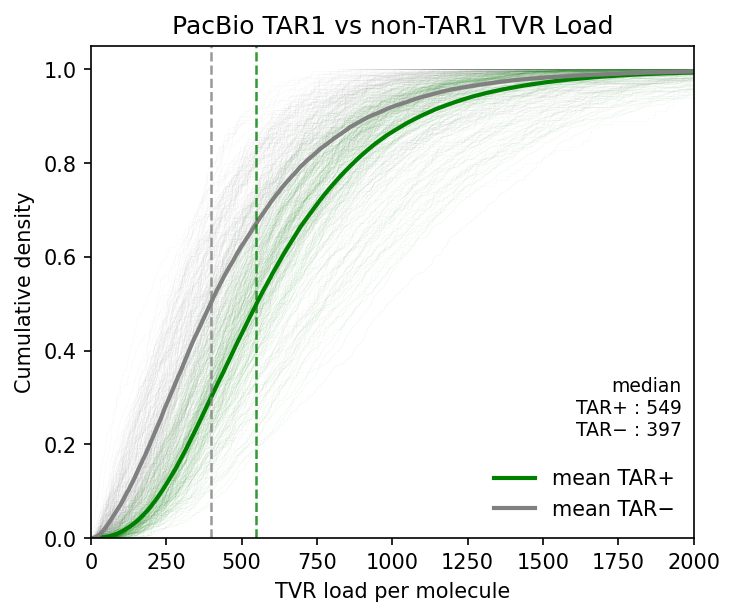

In [100]:
# fig 1H
def cdf_n50(x, cdf, q=0.5):
    x = np.asarray(x)
    cdf = np.asarray(cdf)

    m = np.isfinite(x) & np.isfinite(cdf)
    x = x[m]
    cdf = cdf[m]
    if x.size == 0:
        return np.nan

    # ensure monotone (mean CDF can wiggle slightly)
    cdf = np.maximum.accumulate(cdf)

    if cdf[-1] < q:
        return x[-1]
    if cdf[0] >= q:
        return x[0]

    return float(np.interp(q, cdf, x))
                       
                 
all_pos = []
all_neg = []

plt.figure(figsize=(5, 4), dpi=150)

bin_edges = None

for hprc_tsv in tqdm(pb_hprc_tsvs.values()):
    tvr_pos = hprc_tsv.loc[hprc_tsv["tar_status"], "tvr_load"].to_numpy()
    tvr_neg = hprc_tsv.loc[~hprc_tsv["tar_status"], "tvr_load"].to_numpy()
    if len(tvr_pos) > 0:
        counts, bins, _ = plt.hist(
            tvr_pos, bins=3000, alpha=0.15, density=True,
            range=(0, 3000), cumulative=True,
            lw=0.1, histtype="step", color="green"
        )
        all_pos.append(counts)
        bin_edges = bins

    if len(tvr_neg) > 0:
        counts, bins, _ = plt.hist(
            tvr_neg, bins=3000, alpha=0.15, density=True,
            range=(0, 3000), cumulative=True,
            lw=0.1, histtype="step", color="gray"
        )
        all_neg.append(counts)
        bin_edges = bins

# ---- mean CDF across individuals ----
mean_pos = np.nanmean(np.vstack(all_pos), axis=0)
mean_neg = np.nanmean(np.vstack(all_neg), axis=0)

# x-axis = right bin edges (CDF convention)
x = bin_edges[1:]

plt.plot(x, mean_pos, color="green", lw=2, label="mean TAR+")
plt.plot(x, mean_neg, color="gray",   lw=2, label="mean TAR−")


n50_pos = cdf_n50(x, mean_pos, q=0.5)
n50_neg = cdf_n50(x, mean_neg, q=0.5)

# dashed N50 lines
plt.axvline(n50_pos, color="green", ls="--", lw=1.2, alpha=0.8)
plt.axvline(n50_neg, color="gray",   ls="--", lw=1.2, alpha=0.8)

# annotate bottom-right with mean-group N50s
ax = plt.gca()
ax.text(
    0.98, 0.2,
    f"median\nTAR+ : {n50_pos:,.0f}\nTAR− : {n50_neg:,.0f}",
    transform=ax.transAxes,
    ha="right", va="bottom",
    fontsize=9,
    bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="none", alpha=0.7),
)
plt.xlim(0, 2_000)
plt.xlabel("TVR load per molecule")
plt.ylabel("Cumulative density")
plt.legend(frameon=False)
plt.tight_layout()
plt.title('PacBio TAR1 vs non-TAR1 TVR Load')
# plt.savefig('v2/tvr_load_pb_tar_v_nontar.pdf',dpi=300)
plt.show()

100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 51/51 [00:10<00:00,  5.07it/s]


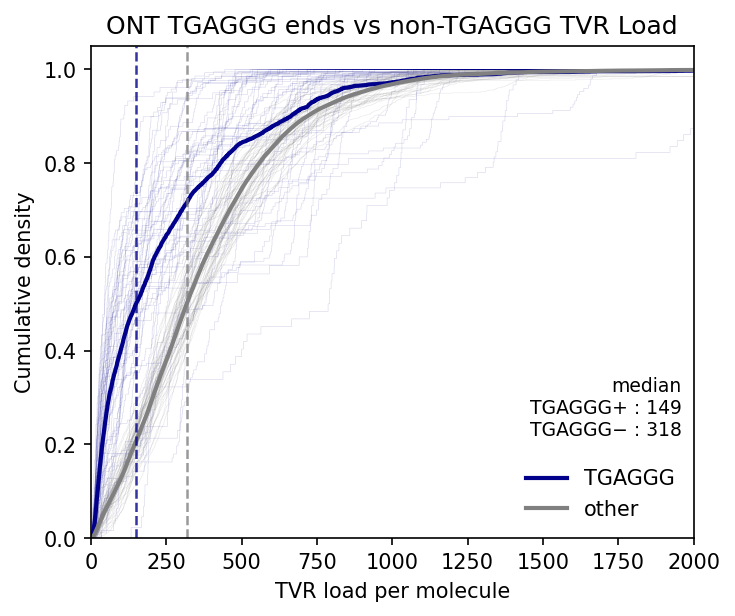

In [102]:
#6a 

all_pos = []
all_neg = []

plt.figure(figsize=(5, 4), dpi=150)

bin_edges = None
tgaggg_chrom_ends = ['chr13p','chr14p','chr15p','chr21p','chrXp','chr17p','chr8q','chr12q']
for hprc_tsv in tqdm(ont_hprc_tsvs.values()):
    idx = np.isin(hprc_tsv["chrom_assignment"], tgaggg_chrom_ends)
    tvr_pos = hprc_tsv.loc[idx, "tvr_load"].to_numpy()
    tvr_neg = hprc_tsv.loc[~idx, "tvr_load"].to_numpy()
    if len(tvr_pos) > 0:
        counts, bins, _ = plt.hist(
            tvr_pos, bins=3000, alpha=0.15, density=True,
            range=(0, 3000), cumulative=True,
            lw=0.3, histtype="step", color="darkblue"
        )
        all_pos.append(counts)
        bin_edges = bins

    if len(tvr_neg) > 0:
        counts, bins, _ = plt.hist(
            tvr_neg, bins=3000, alpha=0.15, density=True,
            range=(0, 3000), cumulative=True,
            lw=0.3, histtype="step", color="gray"
        )
        all_neg.append(counts)
        bin_edges = bins

# ---- mean CDF across individuals ----
mean_pos = np.nanmean(np.vstack(all_pos), axis=0)
mean_neg = np.nanmean(np.vstack(all_neg), axis=0)

# x-axis = right bin edges (CDF convention)
x = bin_edges[1:]

plt.plot(x, mean_pos, color="darkblue", lw=2, label="TGAGGG")
plt.plot(x, mean_neg, color="gray",   lw=2, label="other")

n50_pos = cdf_n50(x, mean_pos, q=0.5)
n50_neg = cdf_n50(x, mean_neg, q=0.5)

plt.axvline(n50_pos, color="darkblue", ls="--", lw=1.2, alpha=0.8)
plt.axvline(n50_neg, color="gray",   ls="--", lw=1.2, alpha=0.8)

ax = plt.gca()
ax.text(
    0.98, 0.2,
    f"median\nTGAGGG+ : {n50_pos:,.0f}\nTGAGGG− : {n50_neg:,.0f}",
    transform=ax.transAxes,
    ha="right", va="bottom",
    fontsize=9,
    bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="none", alpha=0.7),
)
plt.xlim(0, 2_000)
plt.xlabel("TVR load per molecule")
plt.ylabel("Cumulative density")
plt.legend(frameon=False)
plt.tight_layout()
plt.title('ONT TGAGGG ends vs non-TGAGGG TVR Load')
# plt.savefig('tvr_load_ont_tgaggg.pdf',dpi=300)
plt.show()

Processing chr12q: 100%|█████████████████████████████████████████████████████████████████████████████| 51/51 [00:00<00:00, 249.77it/s]


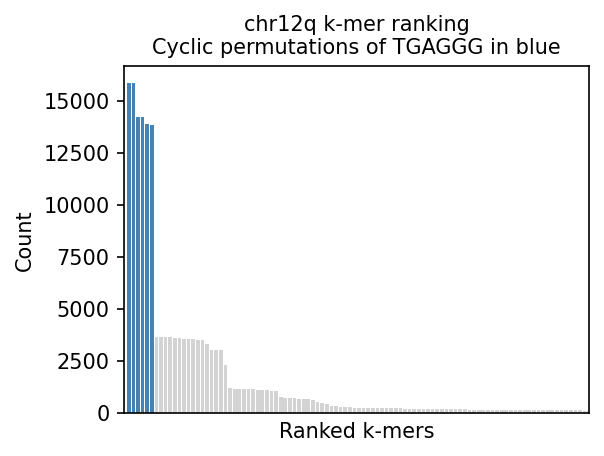


Top 6 k-mers for chr12q:
  GAGGGT: 15872
  TGAGGG: 15848
  GTGAGG: 14223
  GGTGAG: 14206
  GGGTGA: 13901
  AGGGTG: 13816


Processing chr8q: 100%|██████████████████████████████████████████████████████████████████████████████| 51/51 [00:00<00:00, 309.70it/s]


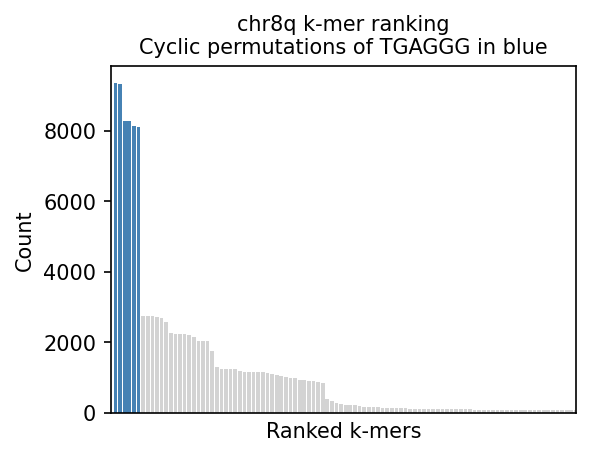


Top 6 k-mers for chr8q:
  GAGGGT: 9365
  TGAGGG: 9337
  GTGAGG: 8273
  GGTGAG: 8263
  GGGTGA: 8141
  AGGGTG: 8116


Processing chrXp: 100%|██████████████████████████████████████████████████████████████████████████████| 51/51 [00:00<00:00, 619.85it/s]


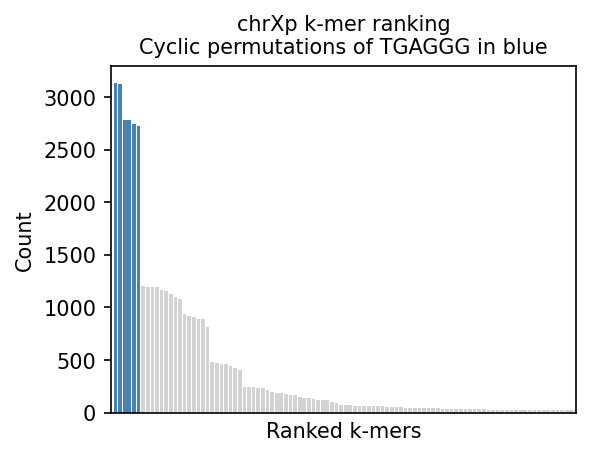


Top 6 k-mers for chrXp:
  TGAGGG: 3136
  GAGGGT: 3125
  GGTGAG: 2783
  GTGAGG: 2782
  GGGTGA: 2739
  AGGGTG: 2721


In [105]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

def get_kmer_composition(all_tsvs, chrom, k=6, min_size=24, teloseq_col="teloseq", tvr_col="tvr"):
    """
    Collect k-mer counts from TVR regions across multiple TSVs for a specified chromosome.
    For each TVR block: iterate from start+k to end-k, taking seq[i:i+k].
    """
    kmer_counts = {}
    
    for tsv in tqdm(all_tsvs.values(), desc=f"Processing {chrom}"):
        # Filter dataframe for the specific chromosome end
        df_chrom = tsv[tsv['chrom_assignment'] == chrom]
        
        for _, r in df_chrom.iterrows():
            seq = str(r.get(teloseq_col, "")).upper()
            L = len(seq)
            if L < k:
                continue

            tvr_blocks = r.get(tvr_col, None)
            if tvr_blocks is None or len(tvr_blocks) == 0:
                continue
            
            try:
                arr = np.array(tvr_blocks, dtype=int).reshape(-1, 2)
            except ValueError:
                continue # Skip if tvr_blocks cannot be reshaped
                
            for s, size in arr:
                if size > min_size:
                    # Offset the start and end according to your original logic
                    start = max(0, s)
                    end = min(L, s + size)
                    
                    for i in range(start, end):
                        if i + k <= L:
                            kmer = seq[i:i+k]
                            if "N" not in kmer:
                                kmer_counts[kmer] = kmer_counts.get(kmer, 0) + 1

    return kmer_counts


def is_cyclic_permutation(kmer, motif):
    """
    Checks if a k-mer is a cyclic permutation of a target motif.
    """
    if len(kmer) != len(motif):
        return False
    # If a string is a cyclic permutation of another, 
    # it will always be a substring of that string doubled.
    return kmer in (motif * 2)


def plot_ranked_kmers(kmer_counts, chrom, motif_to_highlight, top_n=None, figsize=(4, 3), dpi=150):
    """
    Plots a ranked bar chart of k-mers, highlighting cyclic permutations of a target motif.
    """
    if not kmer_counts:
        print(f"No k-mers found to plot for {chrom}.")
        return

    # Sort kmers by count (descending)
    items = sorted(kmer_counts.items(), key=lambda x: x[1], reverse=True)
    if top_n is not None:
        items = items[:top_n]

    kmers, counts = zip(*items)
    counts = np.asarray(counts)
    x = np.arange(len(counts))

    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    
    # Assign colors dynamically based on the passed motif
    colors = [
        "steelblue" if is_cyclic_permutation(k, motif=motif_to_highlight) else "lightgray"
        for k in kmers
    ]

    ax.bar(x, counts, color=colors)

    ax.set_xticks([])
    ax.set_xlabel("Ranked k-mers")
    ax.set_ylabel("Count")

    plt.xlim(-1, min(100, len(kmers))) 

    plt.title(f'{chrom} k-mer ranking\nCyclic permutations of {motif_to_highlight} in blue', fontsize=10)
#     plt.tight_layout()
    
    save_name = f'{chrom}_{motif_to_highlight}_kmer_ranking.pdf'
    plt.savefig(save_name, dpi=300)
    plt.show()

    # Print the top 6 k-mers
    print(f"\nTop 6 k-mers for {chrom}:")
    for k, c in items[:6]:
        print(f"  {k}: {c}")


# running


target_chrom = 'chr12q'
target_motif = 'TGAGGG'
k_size = len(target_motif) 
counts = get_kmer_composition(ont_hprc_tsvs, chrom=target_chrom, k=k_size)
plot_ranked_kmers(counts, chrom=target_chrom, motif_to_highlight=target_motif)


target_chrom = 'chr8q'
target_motif = 'TGAGGG'
k_size = len(target_motif) 
counts = get_kmer_composition(ont_hprc_tsvs, chrom=target_chrom, k=k_size)
plot_ranked_kmers(counts, chrom=target_chrom, motif_to_highlight=target_motif)

target_chrom = 'chrXp'
target_motif = 'TGAGGG'
k_size = len(target_motif) 
counts = get_kmer_composition(ont_hprc_tsvs, chrom=target_chrom, k=k_size)
plot_ranked_kmers(counts, chrom=target_chrom, motif_to_highlight=target_motif)



100%|████████████████████████████████████████████████████████████████████████████████████████████| 212/212 [00:00<00:00, 52630.51it/s]


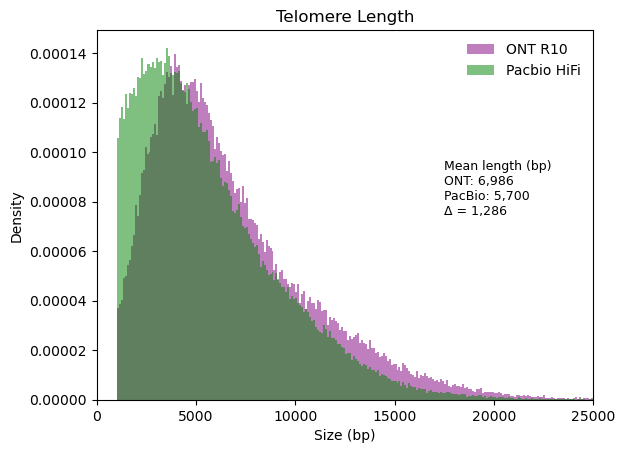

In [110]:
#S5

def getLengthDistribution(tsv_dict):
    all_lens = []
    for individual,df in tqdm(tsv_dict.items()):
        
        all_lens.append(df.centered_query_end)
    return np.concatenate(all_lens)
ont_length_dist = getLengthDistribution(ont_hprc_tsvs)
pacbio_length_dist = getLengthDistribution(pb_hprc_tsvs)


plt.hist(ont_length_dist,bins=1000,range=(1,100000),alpha=0.5,density=True,fc='purple',label='ONT R10')
plt.hist(pacbio_length_dist,bins=1000,range=(1,100000),alpha=0.5,density=True,fc='green',label='Pacbio HiFi')
plt.xlim(0,25000)
plt.ylabel('Density')
plt.xlabel('Size (bp)')
plt.title('Telomere Length')
plt.legend(frameon=False)

ont_mean = np.mean(ont_length_dist)
pb_mean  = np.mean(pacbio_length_dist)

mean_diff = ont_mean - pb_mean
ax = plt.gca()
ax.text(
    0.7, 0.5,
    f"Mean length (bp)\n"
    f"ONT: {ont_mean:,.0f}\n"
    f"PacBio: {pb_mean:,.0f}\n"
    f"Δ = {mean_diff:,.0f}",
    transform=ax.transAxes,    fontsize=9,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="none", alpha=0.7),
)
plt.show()

In [111]:
from pybedtools import BedTool


In [24]:

tar1_df = pd.read_csv("data_for_submission/all_tar1.clean.bed", 
                      sep="\t", 
                      header=None, 
                      usecols=[0,1,2,3],
                      names=['contig','start','stop','sat_name'])



telo_df = pd.read_csv("data_for_submission/all_telos.bed.gz", 
                      sep="\t", 
                      header=None, 
                      usecols=[0,1,2,3],
                      names=['contig','start','stop','direction'])


telo_alias = pd.read_csv("data_for_submission/all_diploid_alias.txt", 
                      sep="\t", 
                      header=None, 
                      usecols=[0,1,2],
                      names=['contig','chrom_alias','contig_name'])




In [30]:
# assign_tar1_chrom_arm_and_relative_coords
def assign_tar1_chrom_arm_and_relative_coords(tar1_df, telo_df, telo_alias,
                                              boundary_cutoff=100_000):
    tar1 = tar1_df.copy()
    telo = telo_df.copy()
    alias = telo_alias.copy()


    #Add chrom_alias to both TAR1 and telomere tables
        
    tar1 = tar1.merge(
        alias[["contig", "chrom_alias"]],
        on="contig",
        how="left"
    )

    telo = telo.merge(
        alias[["contig", "chrom_alias"]],
        on="contig",
        how="left"
    )

    # For each telomere, define the inner boundary
    #    If telomere starts at 0, boundary = stop (end of tel tract)
    #    otherwise boundary = start (start of tel tract at right end)
    def tel_boundary(row):
        if row["start"] == 0:
            return row["stop"]
        else:
            return row["start"]

    telo["boundary"] = telo.apply(tel_boundary, axis=1)

    # Assign arm based on boundary position:
    #    boundary <= 100 kb => p arm, else q arm
    telo["arm"] = np.where(telo["boundary"] <= boundary_cutoff, "p", "q")

    # Attach all telomeres on the same contig (and chrom_alias) to each TAR1
    #    so each TAR1 can "see" both p and q ends on that contig, if present
    merged = tar1.merge(
        telo[["contig", "chrom_alias", "boundary", "arm"]],
        on=["contig"],
        how="left",
        suffixes=("", "_telo")
    )

    #For each TAR1, compute distance to each telomere boundary
    start = merged["start"]
    stop = merged["stop"]
    bnd = merged["boundary"]

    # if boundary falls inside TAR1 interval, distance = 0
    inside = (start <= bnd) & (stop >= bnd)
    dist = np.where(
        inside,
        0,
        np.minimum(np.abs(start - bnd), np.abs(stop - bnd))
    )

    merged["dist_to_boundary"] = dist

    # For each TAR1 (contig, start, stop), keep only closest telomere
    merged = (
        merged
        .sort_values(["contig", "start", "stop", "dist_to_boundary"])
        .groupby(["contig", "start", "stop"], as_index=False)
        .first()
    )

    # Rebase TAR1 coordinates relative to that closest telomere boundary
    merged["start_rel"] = merged["start"] - merged["boundary"]
    merged["stop_rel"]  = merged["stop"]  - merged["boundary"]

    # Final tidy dataframe
    cols = [
        "contig",
        "chrom_alias",
        "arm",        # p / q based on telomere boundary
        "start",
        "stop",
        "start_rel",  # relative to closest telomere boundary on this contig
        "stop_rel",
    ]
    if "sat_name" in merged.columns:
        cols.append("sat_name")

    return merged[cols]

In [31]:
aliased_relative_df = assign_tar1_chrom_arm_and_relative_coords(tar1_df,telo_df,telo_alias)

24it [00:18,  1.28it/s]


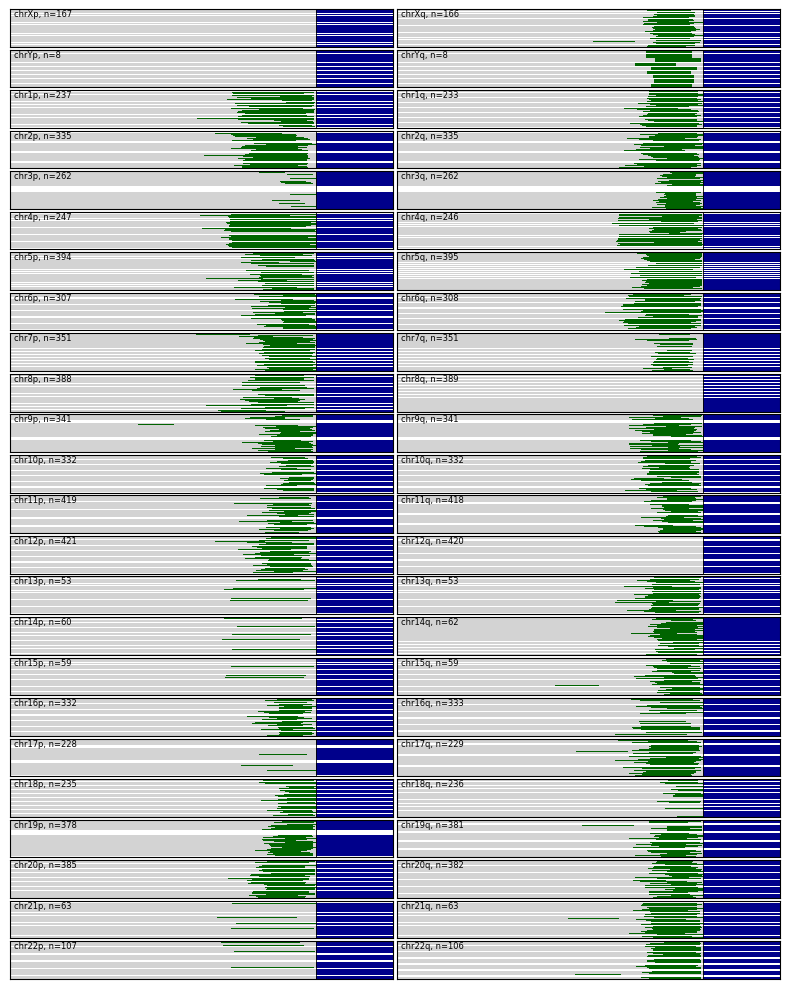

In [32]:
# PLOT ALL ON SAME PAGE
def draw_subtelomere_telomere_tar1_on_ax(
    ax,
    tar1_df,
    telo_df,
    telo_alias,
    chrom_end="chr5q",
    upstream_bp=10_000,       # subtelomere: -10kb..0
    telo_bp=2_500,            # telomere: 0..+1kb
    boundary_cutoff=100_000,  # <100kb -> p, else q
    row_height=0.8,
    subtelo_color="lightgray",
    telo_color="darkblue",
    tar1_color="darkgreen"
):
    """
    Draw one chrom arm (e.g. 'chr5q') on the provided axes `ax`.
    - Subtelomere [-upstream_bp, 0] in gray
    - Telomere [0, telo_bp] in blue (always)
    - TAR1 in subtelomere in green (TAR1 entering telomere is removed)
    - No y-ticks/labels set here (wrapper will handle global styling)
    """
    chrom_alias = chrom_end[:-1]
    arm_target = chrom_end[-1]

    # ---------- 1. Telomere boundaries ----------
    telo = telo_df.merge(
        telo_alias[["contig", "chrom_alias"]],
        on="contig",
        how="left"
    ).copy()

    start_t = telo["start"].to_numpy()
    stop_t  = telo["stop"].to_numpy()

    # Inner boundary of telomere
    boundary = np.where(start_t == 0, stop_t, start_t)
    telo["boundary"] = boundary

    # Assign arm by boundary position along contig
    telo["arm"] = np.where(telo["boundary"] <= boundary_cutoff, "p", "q")

    # Filter to this chrom_end
    telo_sub = telo[
        (telo["chrom_alias"] == chrom_alias) &
        (telo["arm"] == arm_target)
    ].copy()

    if telo_sub.empty:
        # nothing to draw
        ax.set_xlim(-upstream_bp, telo_bp)
        ax.set_ylim(-0.5, 0.5)
        return

    # One telomere per contig
    telo_sub = (
        telo_sub
        .sort_values("boundary")
        .groupby("contig", as_index=False)
        .first()
    )

    contigs = telo_sub["contig"].tolist()
    n_rows = len(contigs)

    # ---------- 2. TAR1 relative coords ----------
    tar1 = tar1_df[tar1_df["sat_name"].str.contains("TAR1")].copy()

    # Attach boundary, chrom_alias, arm to TAR1
    tar1 = tar1.merge(
        telo_sub[["contig", "chrom_alias", "arm", "boundary"]],
        on="contig",
        how="inner"
    )

    if tar1.empty:
        tar1_by_contig = {}
    else:
        b = tar1["boundary"].to_numpy()
        s = tar1["start"].to_numpy()
        e = tar1["stop"].to_numpy()

        is_p = tar1["arm"] == "p"
        is_q = ~is_p

        start_rel = np.empty_like(b, float)
        stop_rel  = np.empty_like(b, float)

        # p-arm: rel = boundary - coord  (subtelomere negative)
        start_rel[is_p.to_numpy()] = b[is_p.to_numpy()] - e[is_p.to_numpy()]
        stop_rel[is_p.to_numpy()]  = b[is_p.to_numpy()] - s[is_p.to_numpy()]

        # q-arm: rel = coord - boundary  (subtelomere negative)
        start_rel[is_q.to_numpy()] = s[is_q.to_numpy()] - b[is_q.to_numpy()]
        stop_rel[is_q.to_numpy()]  = e[is_q.to_numpy()] - b[is_q.to_numpy()]

        # Ensure start_rel < stop_rel
        sr_min = np.minimum(start_rel, stop_rel)
        sr_max = np.maximum(start_rel, stop_rel)
        tar1["start_rel"] = sr_min
        tar1["stop_rel"]  = sr_max

        # Remove TAR1 that enters telomere (any part > 0)
        tar1 = tar1[tar1["stop_rel"] <= 0].copy()

        # Clip to plotting window for speed
        win_min = -upstream_bp
        win_max = telo_bp
        tar1 = tar1[
            (tar1["stop_rel"] > win_min) &
            (tar1["start_rel"] < win_max)
        ].copy()

        tar1_by_contig = {
            ctg: sub[["start_rel", "stop_rel"]].to_numpy()
            for ctg, sub in tar1.groupby("contig")
        }

    # ---------- 3. Draw rectangles ----------
    win_min = -upstream_bp
    win_max = telo_bp

    for row_idx, ctg in enumerate(contigs):
        y = row_idx

        # Subtelomere: [-upstream_bp, 0] (gray)
        ax.add_patch(Rectangle(
            (-upstream_bp, y - row_height/2),
            upstream_bp,
            row_height,
            facecolor=subtelo_color,
            edgecolor=None
        ))

        # Telomere: [0, telo_bp] (blue)
        ax.add_patch(Rectangle(
            (0, y - row_height/2),
            telo_bp,
            row_height,
            facecolor=telo_color,
            edgecolor=None
        ))

        # TAR1 overlays, if any
        intervals = tar1_by_contig.get(ctg)
        if intervals is not None:
            for s_rel, e_rel in intervals:
                s_clip = max(s_rel, win_min)
                e_clip = min(e_rel, win_max)
                if e_clip <= s_clip:
                    continue

                ax.add_patch(Rectangle(
                    (s_clip, y - row_height/2),
                    e_clip - s_clip,
                    row_height,
                    facecolor=tar1_color,
                    edgecolor=None
                ))

    ax.set_xlim(win_min, win_max)
    ax.set_ylim(-0.5, n_rows - 0.5)

    # Boundary line at 0
    ax.axvline(0, color="black", linewidth=0.6)

    # No y-ticks / labels here
    ax.set_yticks([])
    ax.set_yticklabels([])

    # Remove x-ticks here; wrapper will control bottom row ticks
    ax.set_xticks([])
    ax.set_xticklabels([])

    # Minimal in-panel label for chrom name
    ax.text(
        win_min + 0.01 * (win_max - win_min),
        n_rows - 0.5,
        f"{chrom_end}, n={y}",
        fontsize=6,
        va="top",
        ha="left"
    )
    
def plot_all_chroms_single_page(
    tar1_df,
    telo_df,
    telo_alias,
    canonical_arms,
    upstream_bp=10_000,
    telo_bp=1_000,
    boundary_cutoff=100_000,outname=None
):
    """
    Make a single-page figure:
      - one row/subplot per chrom_end in canonical_arms
      - no x/y axis labels in subplots
      - only bottom row has x-ticks with bp values
    """
    arms_set = set(canonical_arms)

    # get unique chrom names (drop arm letter)
    chroms = sorted({arm[:-1] for arm in canonical_arms},
                    key=lambda c: (
                        0 if c == "chrX" else 1 if c == "chrY" else 2,
                        int(c[3:]) if c[3:].isdigit() else 999
                    ))

    n_rows = len(chroms)
    fig, axes = plt.subplots(
        nrows=n_rows,
        ncols=2,
        sharex=True,
        figsize=(8, 10)
    )

    # if only one chrom, axes comes as 1D
    if n_rows == 1:
        axes = np.array([axes])

    for row_idx, chrom in tqdm(enumerate(chroms)):
        ax_left  = axes[row_idx, 0]
        ax_right = axes[row_idx, 1]

        arm_p = chrom + "p"
        arm_q = chrom + "q"

        # left: p arm
        if arm_p in arms_set:
            draw_subtelomere_telomere_tar1_on_ax(
                ax=ax_left,
                tar1_df=tar1_df,
                telo_df=telo_df,
                telo_alias=telo_alias,
                chrom_end=arm_p,
                upstream_bp=upstream_bp,
                telo_bp=telo_bp,
                boundary_cutoff=boundary_cutoff
            )
        else:
            # blank panel with chrom label
            ax_left.set_xlim(-upstream_bp, telo_bp)
            ax_left.set_ylim(-0.5, 0.5)
            ax_left.set_xticks([])
            ax_left.set_yticks([])
            n_contigs_p = telo_sub[telo_sub["arm"] == "p"].shape[0]
            ax_left.text(
                -upstream_bp + 0.01 * (upstream_bp + telo_bp),
                0.4,
                f"{arm_p}, n={n_contigs_p}",
                fontsize=6,
                va="top",
                ha="left"
            )

        # right: q arm
        if arm_q in arms_set:
            draw_subtelomere_telomere_tar1_on_ax(
                ax=ax_right,
                tar1_df=tar1_df,
                telo_df=telo_df,
                telo_alias=telo_alias,
                chrom_end=arm_q,
                upstream_bp=upstream_bp,
                telo_bp=telo_bp,
                boundary_cutoff=boundary_cutoff
            )
        else:
            ax_right.set_xlim(-upstream_bp, telo_bp)
            ax_right.set_ylim(-0.5, 0.5)
            ax_right.set_xticks([])
            ax_right.set_yticks([])
            n_contigs_q = telo_sub[telo_sub["arm"] == "q"].shape[0]

            ax_right.text(
                -upstream_bp + 0.01 * (upstream_bp + telo_bp),
                0.4,
                f"{arm_q}, n={n_contigs_q}",
                fontsize=6,
                va="top",
                ha="left"
            )

    # x-ticks only on bottom row, both columns
    ticks = [-upstream_bp, 0, telo_bp]
    for col in range(2):
        bottom_ax = axes[-1, col]
        bottom_ax.set_xticks(ticks)
        bottom_ax.set_xticklabels([str(t) for t in ticks], fontsize=7)

    # all other axes: no x-ticks
    for row in range(n_rows - 1):
        for col in range(2):
            axes[row, col].set_xticks([])

    # no axis labels anywhere
    for ax_row in axes:
        for ax in ax_row:
            ax.set_xlabel("")
            ax.set_ylabel("")

    plt.tight_layout(h_pad=0.2, w_pad=0.3)
    if outname:
        plt.savefig(outname,dpi=400)
        plt.show()
    else:
        plt.show()
    
plot_all_chroms_single_page(
    tar1_df=tar1_df,
    telo_df=telo_df,
    telo_alias=telo_alias,
    canonical_arms=canonical_arms,
    upstream_bp=10_000,
    telo_bp=2500,outname=None
)

                         chrom_alias arm  total_contigs  tar1_contigs_10kb  \
0                               chr1   p            238                238   
1                               chr1   q            234                234   
2                              chr10   p            333                271   
3                              chr10   q            333                331   
4     chr10_JAGYVJ020000011.1_random   p              1                  1   
...                              ...  ..            ...                ...   
7953   chrY_JBKACK010000023.1_random   q              1                  1   
7954   chrY_JBKOQU010000024.1_random   q              1                  1   
7955   chrY_JBKOQV010000024.1_random   p              1                  0   
7956   chrY_JBKOQY010000021.1_random   p              1                  1   
7957   chrY_JBKOQY010000025.1_random   p              1                  0   

      prop_tar1_within_10kb  
0                  1.000000  
1  

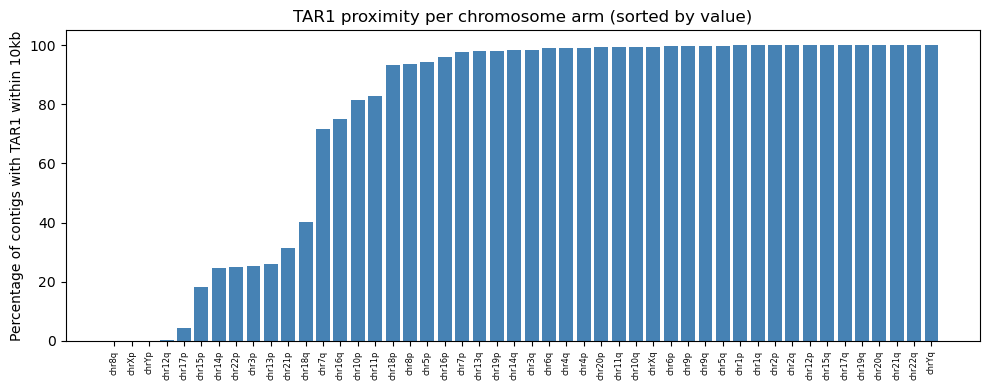

In [124]:
window_bp = 10_000
boundary_cutoff = 100_000

telo = telo_df.merge(
    telo_alias[["contig", "chrom_alias"]],
    on="contig",
    how="left"
).copy()

telo["boundary"] = np.where(telo["start"] == 0, telo["stop"], telo["start"])

# p vs q by boundary position
telo["arm"] = np.where(telo["boundary"] <= boundary_cutoff, "p", "q")

# one row per (contig, chrom_alias, arm, boundary)
telo_ends = telo[["contig", "chrom_alias", "arm", "boundary"]].drop_duplicates()

tar1 = tar1_df[tar1_df["sat_name"].str.contains("TAR1")].copy()

tar1_annot = tar1.merge(
    telo_ends,
    on="contig",
    how="inner"   
)

# For p arms: subtelomere is [boundary, boundary + 10kb)
# For q arms: subtelomere is (boundary - 10kb, boundary]
is_p = tar1_annot["arm"] == "p"
is_q = ~is_p

overlap_p = (
    is_p &
    (tar1_annot["start"] < tar1_annot["boundary"] + window_bp) &
    (tar1_annot["stop"]  > tar1_annot["boundary"])
)

overlap_q = (
    is_q &
    (tar1_annot["start"] < tar1_annot["boundary"]) &
    (tar1_annot["stop"]  > tar1_annot["boundary"] - window_bp)
)

tar1_near = tar1_annot[overlap_p | overlap_q].copy()

with_tar1 = (
    tar1_near
    .groupby(["chrom_alias", "arm"], as_index=False)["contig"]
    .nunique()
    .rename(columns={"contig": "tar1_contigs_10kb"})
)

total = (
    telo_ends
    .groupby(["chrom_alias", "arm"], as_index=False)["contig"]
    .nunique()
    .rename(columns={"contig": "total_contigs"})
)

summary = total.merge(with_tar1, on=["chrom_alias", "arm"], how="left")
summary["tar1_contigs_10kb"] = summary["tar1_contigs_10kb"].fillna(0).astype(int)
summary["prop_tar1_within_10kb"] = (
    summary["tar1_contigs_10kb"] / summary["total_contigs"]
)

print(summary.sort_values(["chrom_alias", "arm"]))
chrom_to_tar1_percentage = {}


for ca in canonical_arms:
    idx = (summary.chrom_alias==ca[:-1]) & (summary.arm==ca[-1])
    
    chrom_to_tar1_percentage[ca] = float(summary[idx].prop_tar1_within_10kb)
                                         
sorted_items = sorted(
    chrom_to_tar1_percentage.items(),
    key=lambda x: x[1]     # ascending; add reverse=True for descending
)

labels = [k for k, v in sorted_items]
values = [v*100 for k, v in sorted_items]

                                           
    
plt.figure(figsize=(10, 4))
plt.bar(labels, values, color="steelblue")

plt.xticks(rotation=90, fontsize=6)
plt.ylabel("Percentage of contigs with TAR1 within 10kb")
plt.title("TAR1 proximity per chromosome arm (sorted by value)")

# ---- Remove minor ticks ----
plt.minorticks_off()          # turns off all minor ticks
ax = plt.gca()
ax.tick_params(axis='x', which='minor', bottom=False)
ax.tick_params(axis='y', which='minor', left=False)

plt.tight_layout()
plt.show()